In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.signal import periodogram
from sklearn.preprocessing import PowerTransformer, QuantileTransformer
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "#f9f8f5", "axes.facecolor": "#f9f8f5",
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10,
})

TEAL   = "#01696f"
MAROON = "#a12c7b"
ORANGE = "#da7101"
SEED   = 42
np.random.seed(SEED)

META_COLS   = ["y_target", "weight", "horizon", "ts_index"]
TARGET      = "y_target"
WEIGHT      = "weight"
HORIZON_COL = "horizon"
TS_COL      = "ts_index"

In [2]:
df = pd.read_parquet("/Users/raresolteanu/Downloads/ts-forecasting/train.parquet")

print(f"Shape        : {df.shape}")
print(f"ts_index range: {df[TS_COL].min()} → {df[TS_COL].max()}")
print(f"Horizons     : {sorted(df[HORIZON_COL].unique())}")
print(f"Codes        : {df['code'].nunique()}")
print(f"Sub-codes    : {df['sub_code'].nunique()}")
print(f"Sub-categories: {df['sub_category'].nunique()}")
print(f"\nDtype counts:")
print(df.dtypes.value_counts())
print(f"\nFirst 5 rows:")
df.head()

Shape        : (5337414, 94)
ts_index range: 1 → 3601
Horizons     : [1, 3, 10, 25]
Codes        : 23
Sub-codes    : 180
Sub-categories: 5

Dtype counts:
float64    86
object      4
int32       3
int64       1
Name: count, dtype: int64

First 5 rows:


,id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,...,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
0,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,25,89,29,16.364093,7.464023,5.966933,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.551324,40.982572
1,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__1__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,1,89,53,2.858806,5.050617,15.906651,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.315583,150.075406
2,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__3__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,3,89,51,9.585452,1.076268,9.004147,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.362894,115.953552
3,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__10__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,10,89,44,8.840588,15.034634,4.170780,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.667023,64.573073
4,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__90,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,25,90,28,2.303825,7.696209,12.896100,...,-0.001622,-0.103809,-0.005135,NaN,-0.174660,2.738606,0.109204,1,-0.437398,41.948761


In [3]:
def detect_first_existing(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

ID_COL_CANDIDATES = ["id", "series_id", "ID"]
ID_COL = detect_first_existing(df.columns, ID_COL_CANDIDATES)
META_COLS = ["y_target", "weight", "horizon", "ts_index"]
TARGET_COL = "y_target"
WEIGHT = "weight"
HORIZON_COL = "horizon"
TS_COL = "ts_index"

print("ID_COL:", ID_COL)
print("TARGET_COL:", TARGET_COL)
print("TS_COL:", TS_COL)

ID_COL: id
TARGET_COL: y_target
TS_COL: ts_index


In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0]
print(f"Columns with missing values: {len(missing_df)}\n")
print(missing_df.head(30).to_string())

Columns with missing values: 48

            missing_count  missing_%
feature_at         665676      12.47
feature_by         588140      11.02
feature_ay         455920       8.54
feature_cd         400114       7.50
feature_ce         275829       5.17
feature_cf         236389       4.43
feature_al         225416       4.22
feature_aw         205194       3.84
feature_bz         151722       2.84
feature_bi         147432       2.76
feature_i           59025       1.11
feature_k           59025       1.11
feature_h           58465       1.10
feature_j           58465       1.10
feature_cg          39644       0.74
feature_av          38654       0.72
feature_au          38447       0.72
feature_ax          38409       0.72
feature_m           38170       0.72
feature_az          11157       0.21
feature_bl          11157       0.21
feature_ad           8906       0.17
feature_r            8906       0.17
feature_n            8906       0.17
feature_ae           8126       0.15
featu

In [5]:
num_features = [c for c in df.select_dtypes(include="number").columns
                if c not in META_COLS]
print(f"Numeric feature columns: {len(num_features)}")
print(num_features)

Numeric feature columns: 86
['feature_a', 'feature_b', 'feature_c', 'feature_d', 'feature_e', 'feature_f', 'feature_g', 'feature_h', 'feature_i', 'feature_j', 'feature_k', 'feature_l', 'feature_m', 'feature_n', 'feature_o', 'feature_p', 'feature_q', 'feature_r', 'feature_s', 'feature_t', 'feature_u', 'feature_v', 'feature_w', 'feature_x', 'feature_y', 'feature_z', 'feature_aa', 'feature_ab', 'feature_ac', 'feature_ad', 'feature_ae', 'feature_af', 'feature_ag', 'feature_ah', 'feature_ai', 'feature_aj', 'feature_ak', 'feature_al', 'feature_am', 'feature_an', 'feature_ao', 'feature_ap', 'feature_aq', 'feature_ar', 'feature_as', 'feature_at', 'feature_au', 'feature_av', 'feature_aw', 'feature_ax', 'feature_ay', 'feature_az', 'feature_ba', 'feature_bb', 'feature_bc', 'feature_bd', 'feature_be', 'feature_bf', 'feature_bg', 'feature_bh', 'feature_bi', 'feature_bj', 'feature_bk', 'feature_bl', 'feature_bm', 'feature_bn', 'feature_bo', 'feature_bp', 'feature_bq', 'feature_br', 'feature_bs', 'fe

Unique series : 5337414
count    5337414.0
mean           1.0
std            0.0
min            1.0
25%            1.0
50%            1.0
75%            1.0
max            1.0


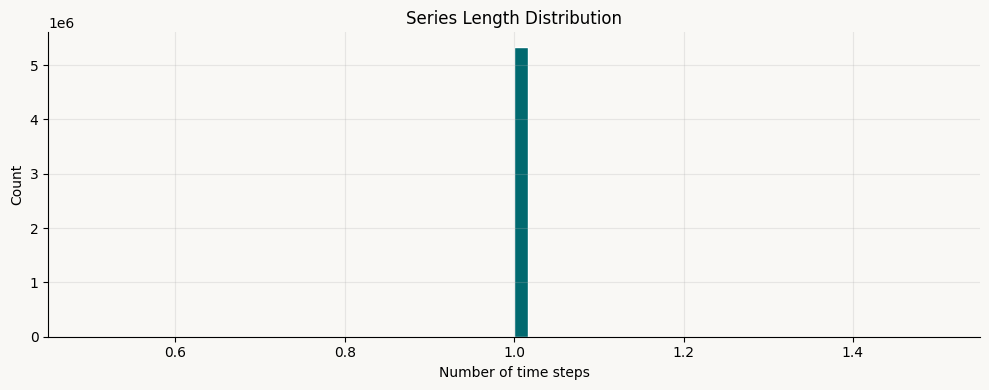

In [6]:
series_lengths = df.groupby("id")[TS_COL].count() if "id" in df.columns else \
                 df.groupby(["code", "sub_code", "sub_category", HORIZON_COL])[TS_COL].count()

print(f"Unique series : {len(series_lengths)}")
print(series_lengths.describe().to_string())

fig, ax = plt.subplots(figsize=(10, 4))
series_lengths.hist(bins=60, ax=ax, color=TEAL, edgecolor="white")
ax.set_title("Series Length Distribution")
ax.set_xlabel("Number of time steps")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

Weight stats:
count    5.337414e+06
mean     1.642788e+07
std      6.027074e+09
min      0.000000e+00
25%      1.553378e+01
50%      1.699384e+03
75%      1.641908e+05
max      1.391222e+13

Zero weights  : 4981
Weight skew   : 2304.3869
Weight kurtosis: 5318967.5699


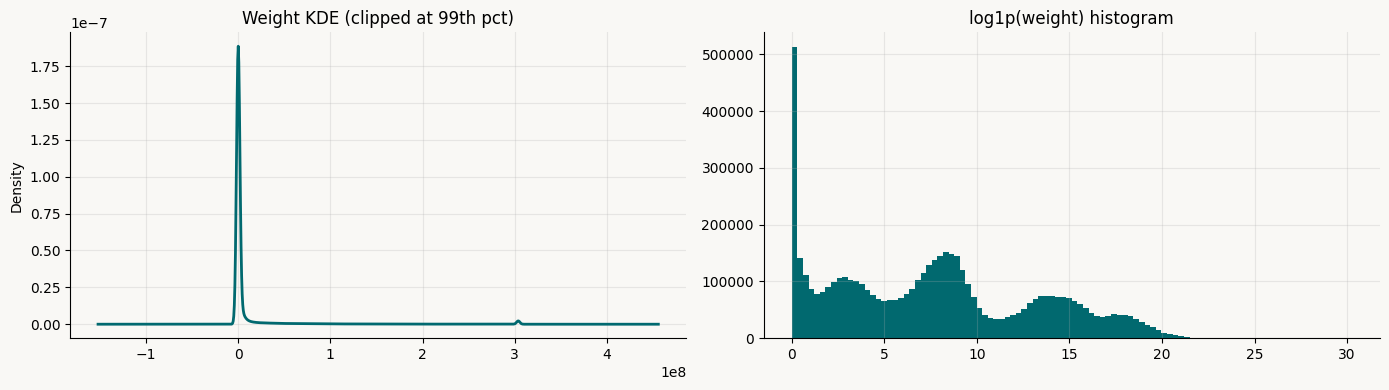

In [7]:
w = df[WEIGHT]
print(f"Weight stats:\n{w.describe().to_string()}")
print(f"\nZero weights  : {(w == 0).sum()}")
print(f"Weight skew   : {w.skew():.4f}")
print(f"Weight kurtosis: {w.kurtosis():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
w.clip(0, w.quantile(0.99)).plot.kde(ax=axes[0], color=TEAL, lw=2)
axes[0].set_title("Weight KDE (clipped at 99th pct)")
axes[1].hist(np.log1p(w), bins=100, color=TEAL)
axes[1].set_title("log1p(weight) histogram")
plt.tight_layout()
plt.show()

Weighted mean y_target per horizon:
  horizon   1  weighted_mean=-0.000006  std=11.6997
  horizon   3  weighted_mean=-0.000004  std=19.3612
  horizon  10  weighted_mean=-0.000044  std=33.8421
  horizon  25  weighted_mean=-0.000070  std=52.8233


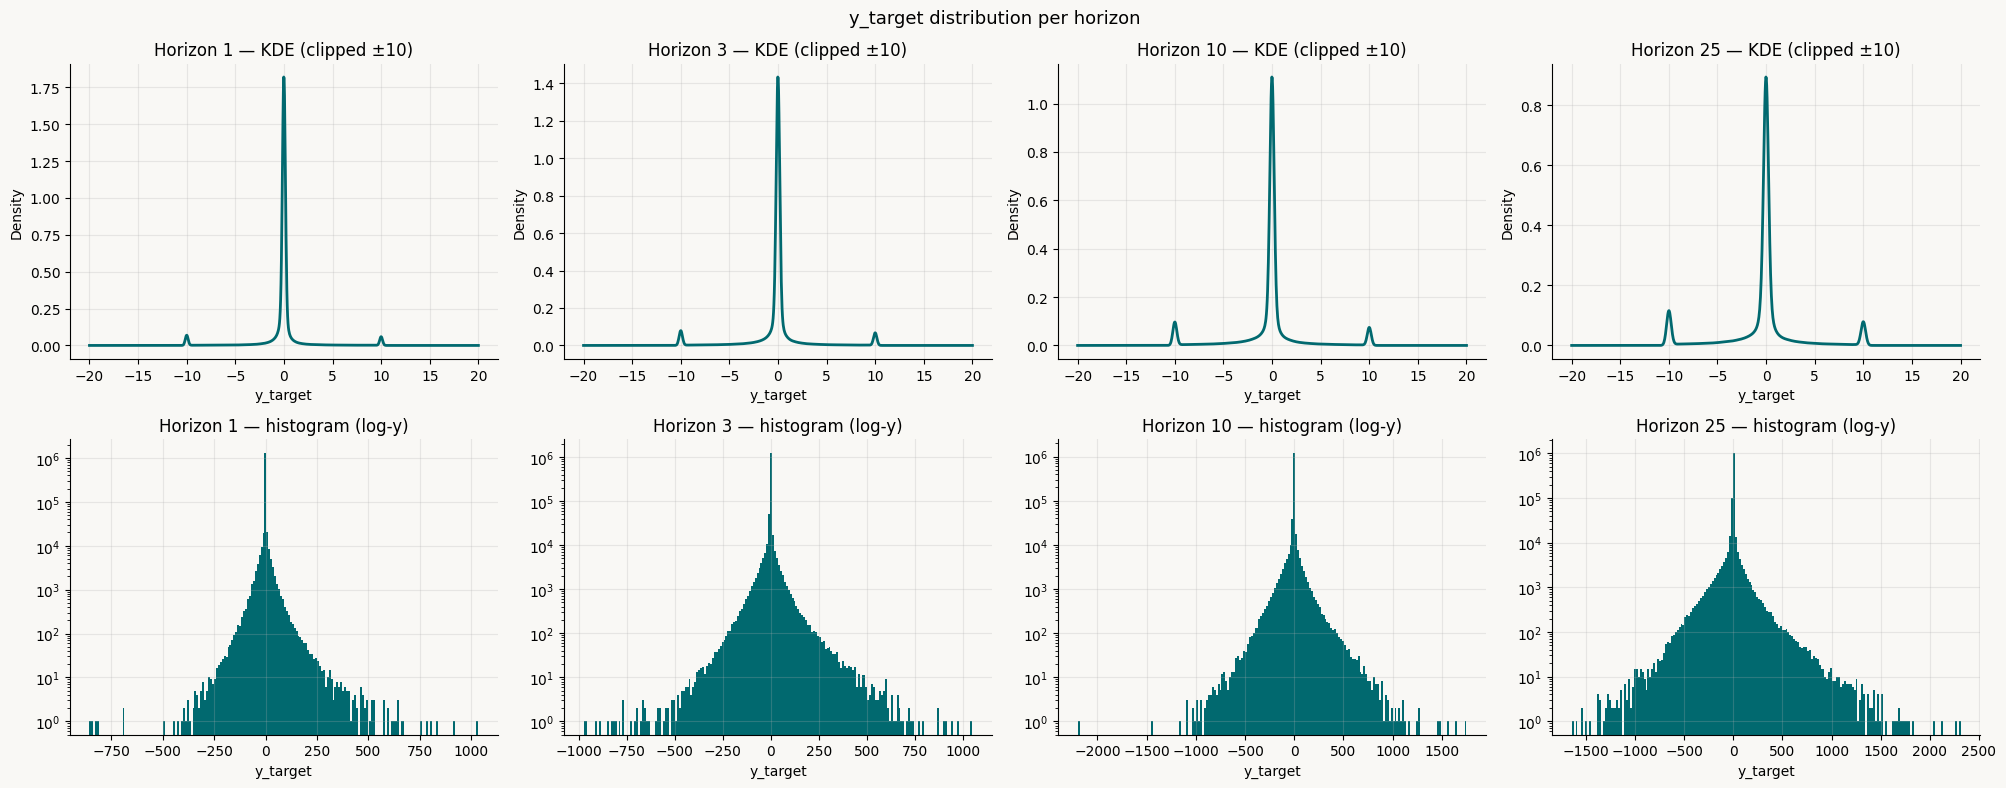

In [8]:
horizons = sorted(df[HORIZON_COL].unique())

print("Weighted mean y_target per horizon:")
for h in horizons:
    sub = df[df[HORIZON_COL] == h]
    wm  = (sub[TARGET] * sub[WEIGHT]).sum() / sub[WEIGHT].sum()
    print(f"  horizon {h:3d}  weighted_mean={wm:.6f}  std={sub[TARGET].std():.4f}")

fig, axes = plt.subplots(2, len(horizons), figsize=(5 * len(horizons), 8))
for i, h in enumerate(horizons):
    sub     = df[df[HORIZON_COL] == h][TARGET]
    clipped = sub.clip(-10, 10)
    clipped.plot.kde(ax=axes[0, i], color=TEAL, lw=2)
    axes[0, i].set_title(f"Horizon {h} — KDE (clipped ±10)")
    axes[0, i].set_xlabel(TARGET)
    axes[1, i].hist(sub, bins=200, color=TEAL, log=True)
    axes[1, i].set_title(f"Horizon {h} — histogram (log-y)")
    axes[1, i].set_xlabel(TARGET)

plt.suptitle("y_target distribution per horizon", fontsize=13)
plt.tight_layout()
plt.show()

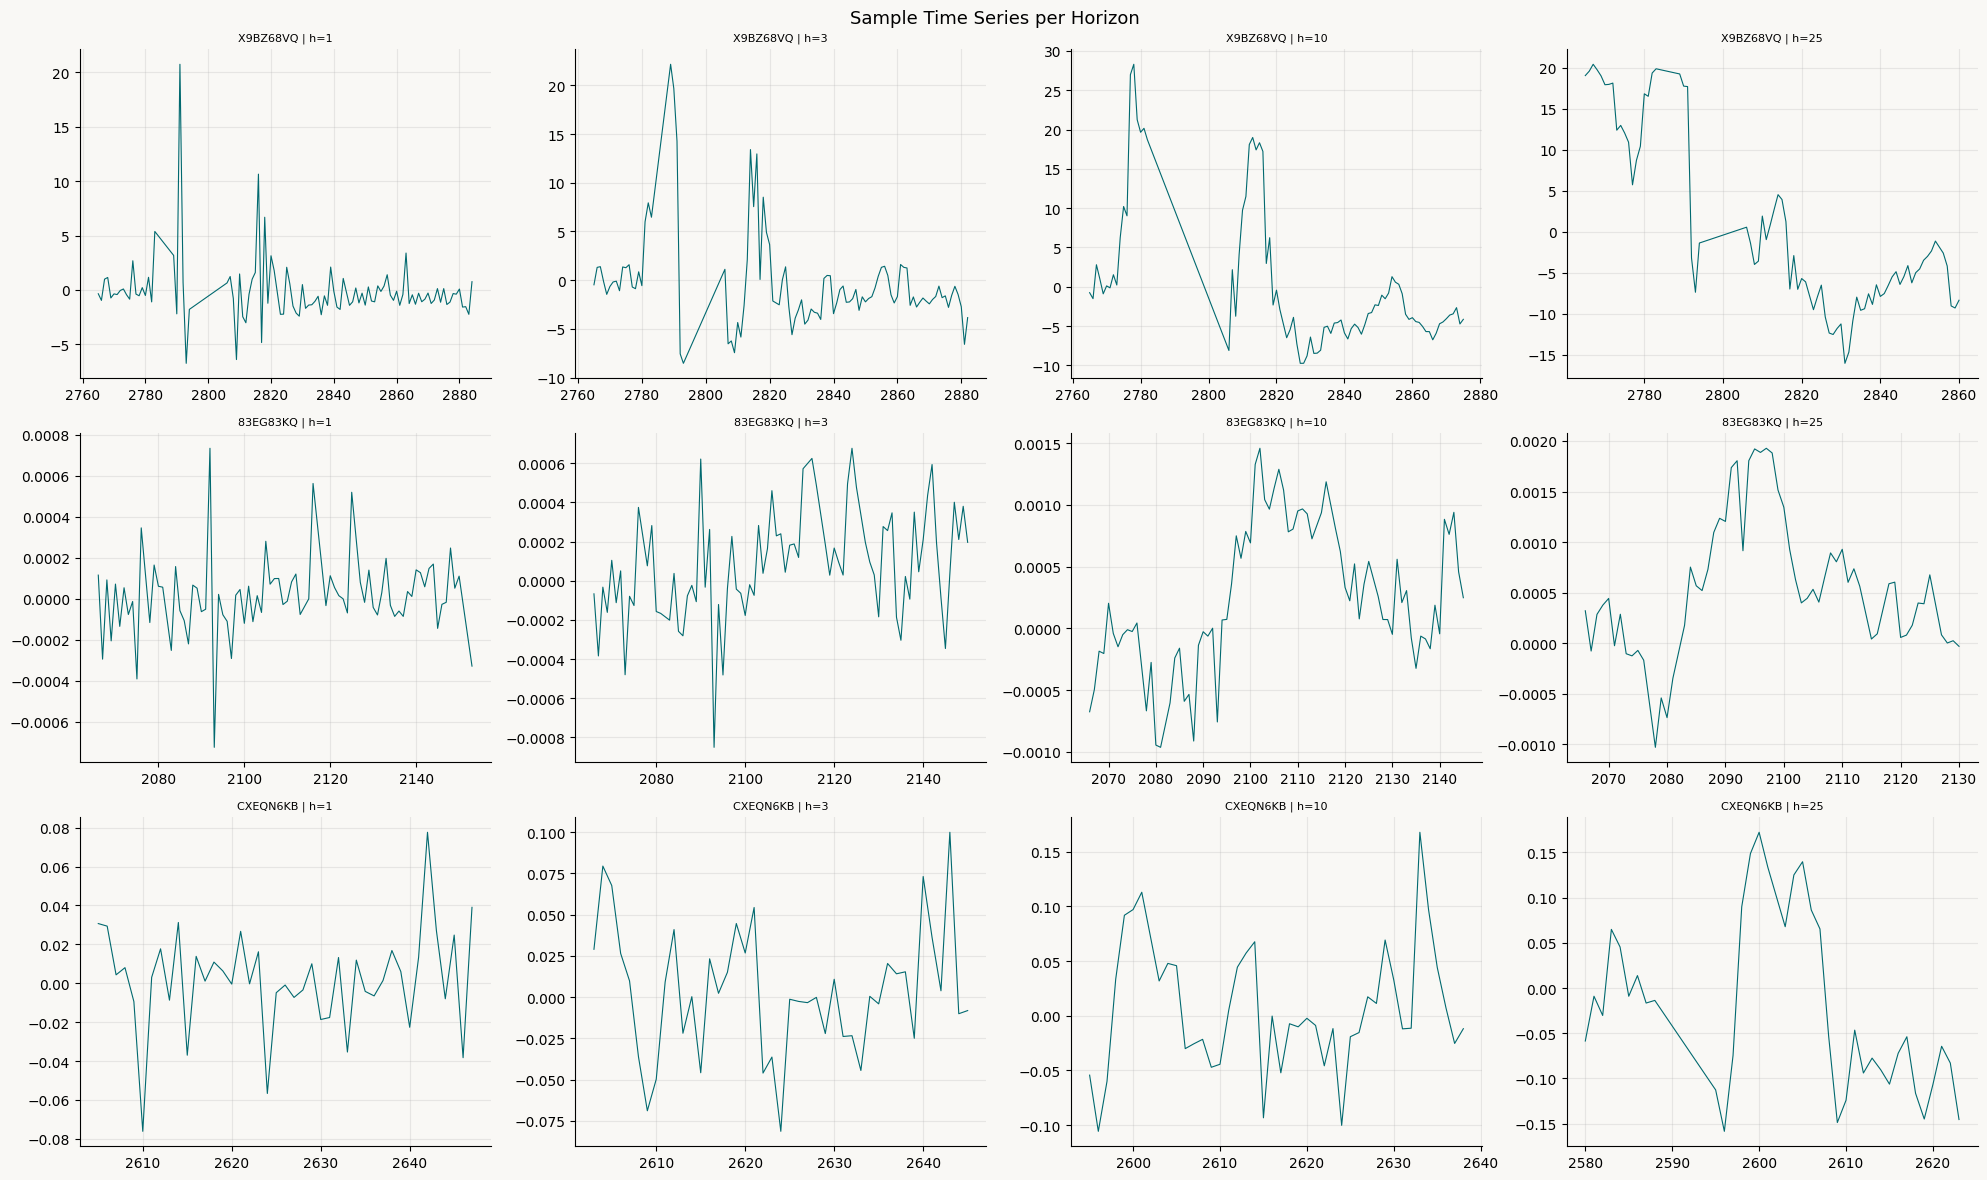

In [9]:
sample_ids = df[["code", "sub_code", "sub_category"]].drop_duplicates().sample(3, random_state=SEED)

fig, axes = plt.subplots(len(sample_ids), len(horizons),
                         figsize=(5 * len(horizons), 4 * len(sample_ids)), squeeze=False)

for row_i, (_, sid) in enumerate(sample_ids.iterrows()):
    mask = ((df["code"] == sid["code"]) &
            (df["sub_code"] == sid["sub_code"]) &
            (df["sub_category"] == sid["sub_category"]))
    for col_i, h in enumerate(horizons):
        sub = df[mask & (df[HORIZON_COL] == h)].sort_values(TS_COL)
        axes[row_i, col_i].plot(sub[TS_COL].values, sub[TARGET].values,
                                color=TEAL, lw=0.8)
        axes[row_i, col_i].set_title(
            f"{sid['code']} | h={h}", fontsize=8)

plt.suptitle("Sample Time Series per Horizon", fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
rows = []

for _, sid in sample_ids.iterrows():
    mask = (
        (df["code"] == sid["code"]) &
        (df["sub_code"] == sid["sub_code"]) &
        (df["sub_category"] == sid["sub_category"])
    )

    for h in horizons:
        sub = df[mask & (df[HORIZON_COL] == h)].sort_values(TS_COL)

        rows.append({
            "code": sid["code"],
            "sub_code": sid["sub_code"],
            "sub_category": sid["sub_category"],
            "horizon": h,
            "min_ts": sub[TS_COL].min() if len(sub) > 0 else np.nan,
            "max_ts": sub[TS_COL].max() if len(sub) > 0 else np.nan,
            "n_obs": len(sub)
        })

sample_ts_ranges = pd.DataFrame(rows)
display(sample_ts_ranges)


,code,sub_code,sub_category,horizon,min_ts,max_ts,n_obs
0,X9BZ68VQ,ZT5R1WKA,DPPUO5X2,1,2765,2884,103
1,X9BZ68VQ,ZT5R1WKA,DPPUO5X2,3,2765,2882,100
2,X9BZ68VQ,ZT5R1WKA,DPPUO5X2,10,2765,2875,87
3,X9BZ68VQ,ZT5R1WKA,DPPUO5X2,25,2765,2860,79
4,83EG83KQ,SE7KARJH,NQ58FVQM,1,2066,2153,81
5,83EG83KQ,SE7KARJH,NQ58FVQM,3,2066,2150,80
6,83EG83KQ,SE7KARJH,NQ58FVQM,10,2066,2145,75
7,83EG83KQ,SE7KARJH,NQ58FVQM,25,2066,2130,60
8,CXEQN6KB,IWOBFO69,NQ58FVQM,1,2605,2647,43
9,CXEQN6KB,IWOBFO69,NQ58FVQM,3,2603,2645,43


In [15]:
subcode_counts = (
    df.groupby("sub_code")
      .size()
      .reset_index(name="n_rows")
      .sort_values("n_rows", ascending=False)
      .reset_index(drop=True)
)

display(subcode_counts)


,sub_code,n_rows
0,69SD4Y3A,69521
1,OYJGNSQK,69390
2,TI04KMOC,68844
3,XT8JWYHT,68515
4,PCXKOBIH,68383
...,...,...
175,R8ECWR4M,1724
176,ODPORHON,834
177,CXK160RR,140
178,SNJ5FTC0,123


In [16]:
subcode_counts = (
    df.groupby("sub_code")
      .size()
      .reset_index(name="n_rows")
)

subcode_counts["percentage"] = 100 * subcode_counts["n_rows"] / len(df)

subcode_counts = subcode_counts.sort_values("percentage", ascending=False).reset_index(drop=True)

display(subcode_counts.round(2))


,sub_code,n_rows,percentage
0,69SD4Y3A,69521,1.30
1,OYJGNSQK,69390,1.30
2,TI04KMOC,68844,1.29
3,XT8JWYHT,68515,1.28
4,PCXKOBIH,68383,1.28
...,...,...,...
175,R8ECWR4M,1724,0.03
176,ODPORHON,834,0.02
177,CXK160RR,140,0.00
178,SNJ5FTC0,123,0.00


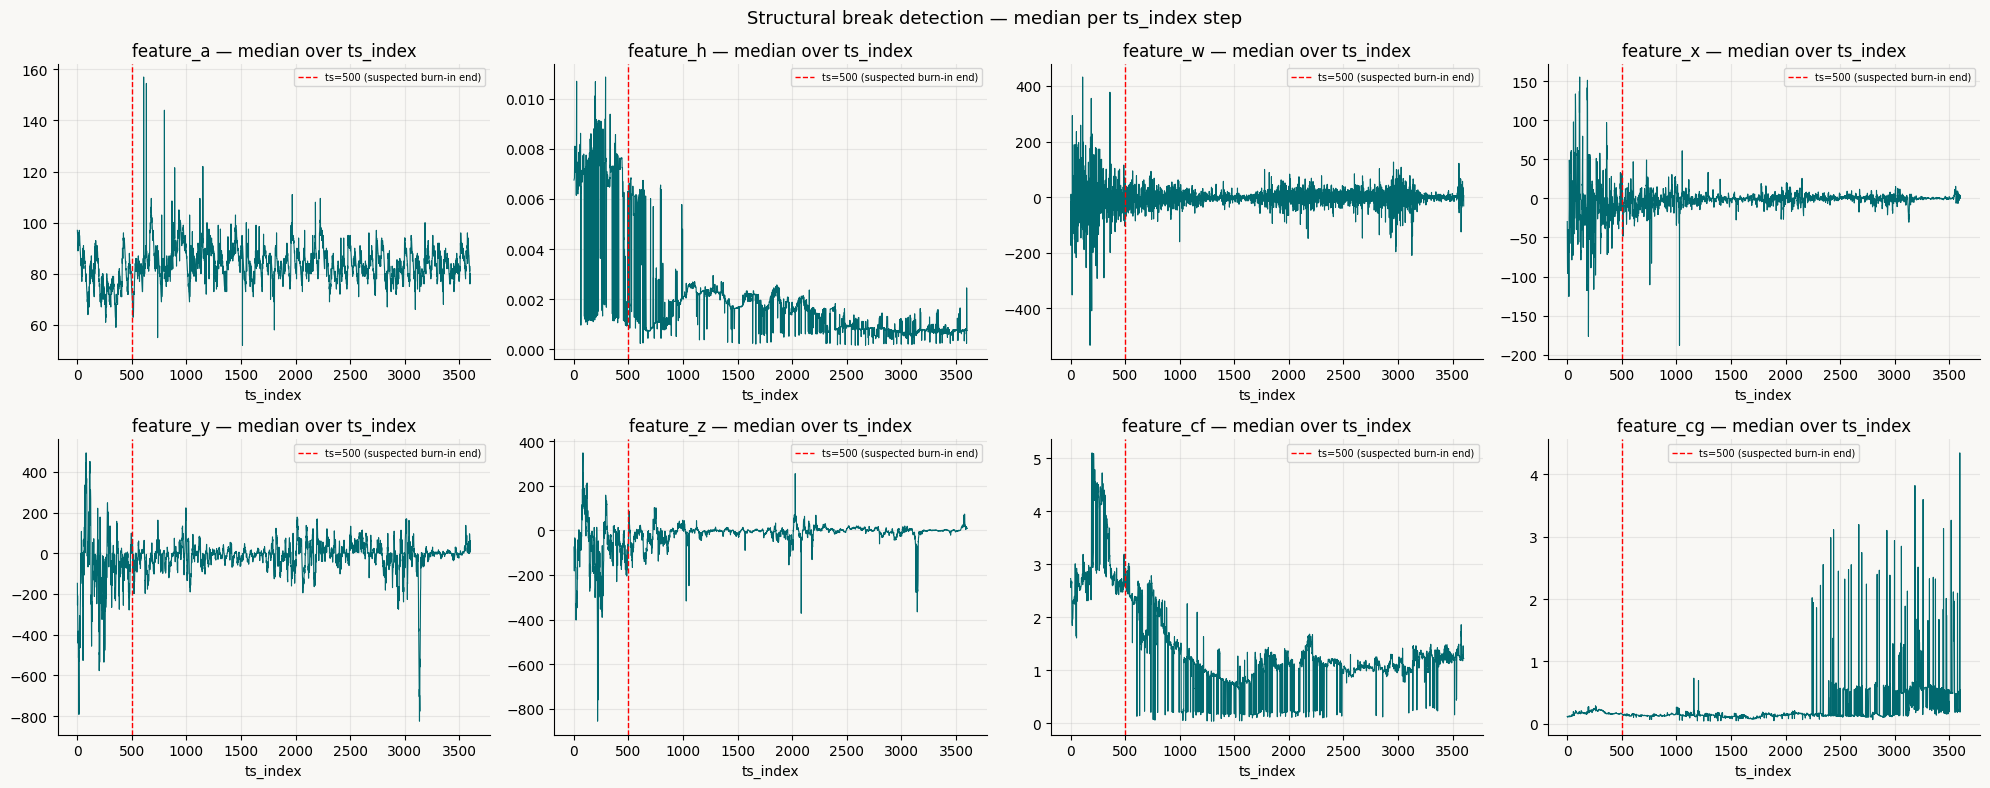

In [10]:
suspect_cols = ["feature_a", "feature_h", "feature_w", "feature_x",
                "feature_y", "feature_z", "feature_cf", "feature_cg"]
suspect_cols = [c for c in suspect_cols if c in df.columns]
if not suspect_cols:
    suspect_cols = num_features[:8]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(suspect_cols[:8]):
    med = df.groupby(TS_COL)[col].median()
    axes[i].plot(med.index, med.values, lw=0.8, color=TEAL)
    axes[i].axvline(500, color="red", ls="--", lw=1, label="ts=500 (suspected burn-in end)")
    axes[i].set_title(f"{col} — median over ts_index")
    axes[i].set_xlabel("ts_index")
    axes[i].legend(fontsize=7)

for j in range(len(suspect_cols), 8):
    axes[j].set_visible(False)

plt.suptitle("Structural break detection — median per ts_index step", fontsize=13)
plt.tight_layout()
plt.show()

In [25]:
feature_cols = [c for c in df.columns if c.startswith("feature_")]

rows = []

for c in feature_cols:
    s = df[c].dropna()

    if len(s) == 0:
        continue

    rows.append({
        "feature": c,
        "mean_abs": s.abs().mean(),
        "std": s.std(),
        "range": s.max() - s.min(),
        "iqr": s.quantile(0.75) - s.quantile(0.25),
        "q95_q05_range": s.quantile(0.95) - s.quantile(0.05),
        "pct_near_zero": (s.abs() < 1e-4).mean() * 100,
        "n_unique_rounded": s.round(6).nunique()
    })

feature_check = pd.DataFrame(rows)

small_low_variation = feature_check[
    (feature_check["mean_abs"] < 0.10) &
    (
        (feature_check["std"] < 1e-2) |
        (feature_check["q95_q05_range"] < 1e-2) |
        (feature_check["n_unique_rounded"] <= 5) |
        (feature_check["pct_near_zero"] > 99)
    )
].sort_values(["std", "q95_q05_range"])

display(small_low_variation.round(6))


,feature,mean_abs,std,range,iqr,q95_q05_range,pct_near_zero,n_unique_rounded
9,feature_j,0.001662,0.002917,0.108760,0.001943,0.006462,18.243688,13657
10,feature_k,0.002480,0.003510,0.023593,0.003981,0.010023,16.467316,16327
8,feature_i,0.005408,0.005883,0.049242,0.008584,0.016399,4.049550,24419
7,feature_h,0.005912,0.007924,0.110952,0.010096,0.021014,0.350486,29201


In [27]:
suspect_features = small_low_variation["feature"].tolist()
print(suspect_features)


['feature_j', 'feature_k', 'feature_i', 'feature_h']


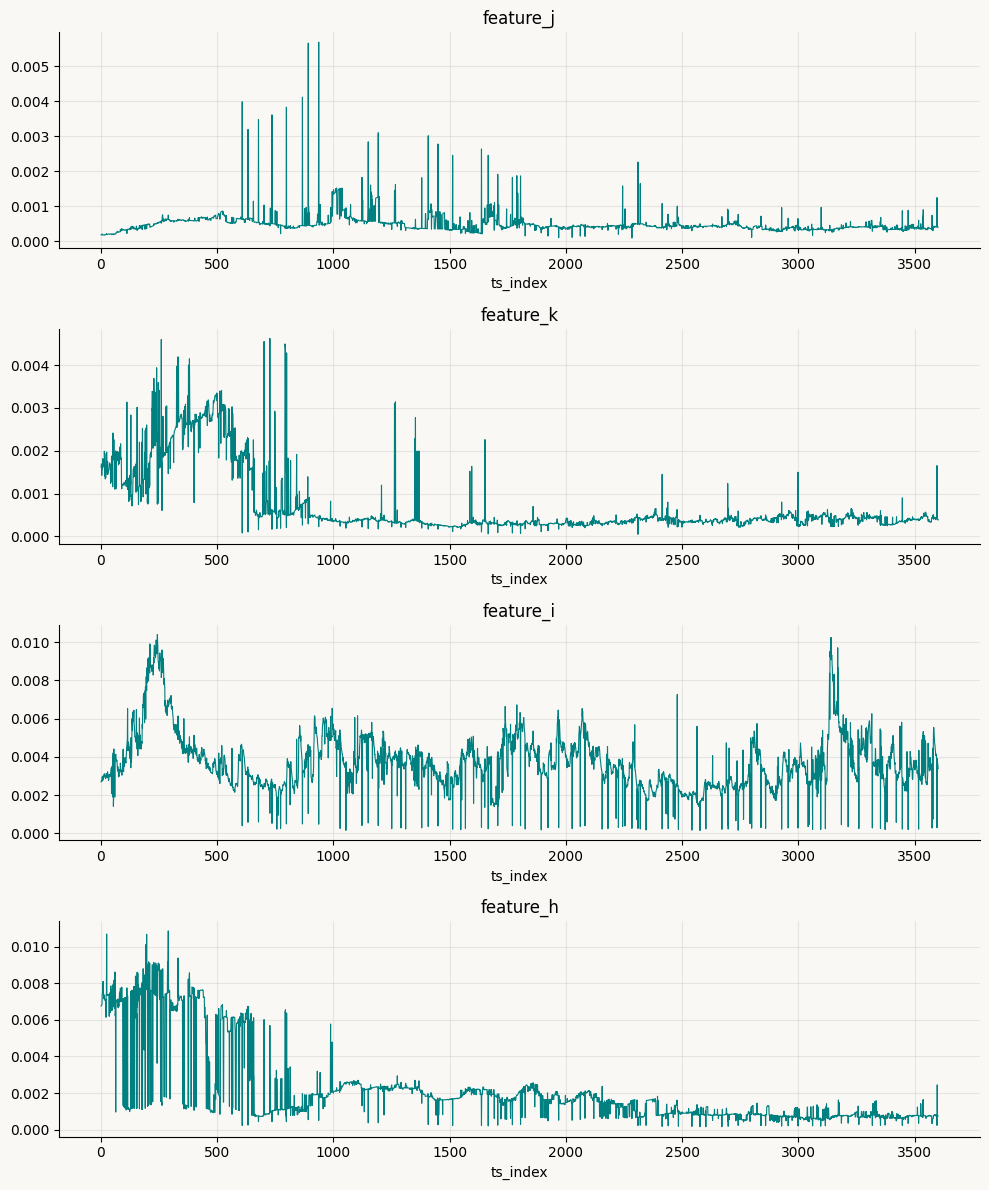

In [29]:
fig, axes = plt.subplots(len(suspect_features), 1,
                         figsize=(10, 3 * len(suspect_features)),
                         squeeze=False)

for i, col in enumerate(suspect_features):
    med = df.groupby(TS_COL)[col].median()
    axes[i, 0].plot(med.index, med.values, color="teal", lw=0.8)
    axes[i, 0].set_title(col)
    axes[i, 0].set_xlabel(TS_COL)

plt.tight_layout()
plt.show()

In [30]:
check_cols = ["feature_j", "feature_k", "feature_i", "feature_h"]

rows = []
for c in check_cols:
    tmp = df[[c, "y_target"]].dropna()
    rows.append({
        "feature": c,
        "corr_with_target": tmp[c].corr(tmp["y_target"]),
        "std": tmp[c].std(),
        "pct_zero": (tmp[c] == 0).mean() * 100
    })

pd.DataFrame(rows)


,feature,corr_with_target,std,pct_zero
0,feature_j,0.008325,0.002917,0.000379
1,feature_k,-0.029943,0.003510,0.000000
2,feature_i,0.004683,0.005883,0.000000
3,feature_h,-0.025394,0.007924,0.000379


In [31]:
feature_cols = [c for c in df.columns if c.startswith("feature_")]

corr_rows = []

for c in feature_cols:
    tmp = df[[c, "y_target"]].dropna()

    corr_rows.append({
        "feature": c,
        "corr_with_y_target": tmp[c].corr(tmp["y_target"]),
        "abs_corr": abs(tmp[c].corr(tmp["y_target"])),
        "n_obs": len(tmp)
    })

feature_target_corr = (
    pd.DataFrame(corr_rows)
    .sort_values("abs_corr", ascending=False)
    .reset_index(drop=True)
)

display(feature_target_corr.round(4))


,feature,corr_with_y_target,abs_corr,n_obs
0,feature_bz,0.0905,0.0905,5185692
1,feature_cd,0.0860,0.0860,4937300
2,feature_af,-0.0735,0.0735,5329288
3,feature_u,-0.0701,0.0701,5330292
4,feature_bo,-0.0582,0.0582,5337414
...,...,...,...,...
81,feature_bi,0.0005,0.0005,5189982
82,feature_g,-0.0002,0.0002,5337414
83,feature_d,0.0001,0.0001,5337414
84,feature_b,-0.0001,0.0001,5337414


In [32]:
threshold = 0.001

drop_cols = feature_target_corr.loc[
    feature_target_corr["abs_corr"] < threshold, "feature"
].tolist()

print("Columns to drop:", len(drop_cols))
print(drop_cols)

df_reduced = df.drop(columns=drop_cols)


Columns to drop: 8
['feature_ak', 'feature_e', 'feature_c', 'feature_bi', 'feature_g', 'feature_d', 'feature_b', 'feature_f']


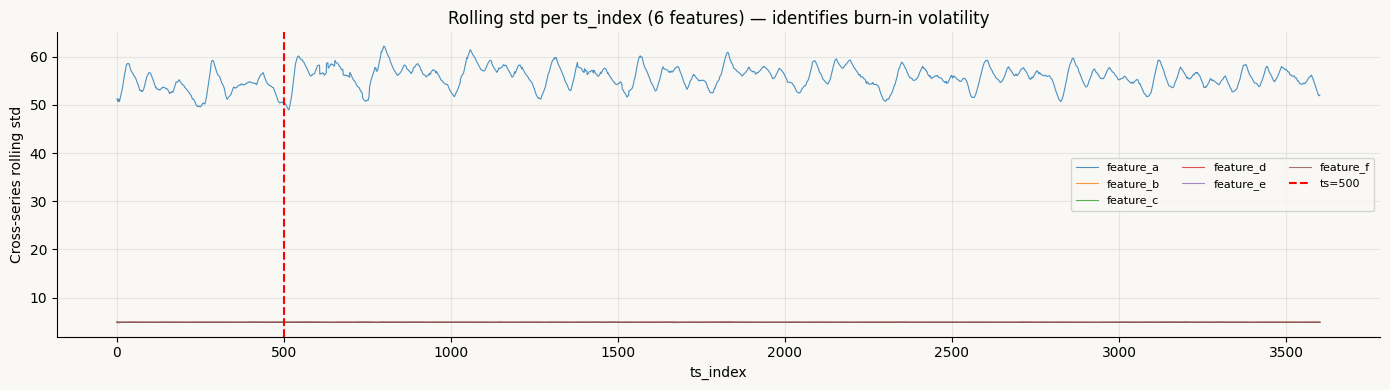

In [35]:
BURNIN_THRESHOLD = 500

fig, ax = plt.subplots(figsize=(14, 4))
for col in num_features[:6]:
    roll_std = df.groupby(TS_COL)[col].std().rolling(20, min_periods=1).mean()
    roll_std.plot(ax=ax, lw=0.8, label=col, alpha=0.8)

ax.axvline(BURNIN_THRESHOLD, color="red", ls="--", lw=1.5, label=f"ts={BURNIN_THRESHOLD}")
ax.set_title("Rolling std per ts_index (6 features) — identifies burn-in volatility")
ax.set_xlabel("ts_index")
ax.set_ylabel("Cross-series rolling std")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

In [36]:
for col in num_features[:6]:
    s = df.groupby(TS_COL)[col].std()
    print(col, s.min(), s.max())


feature_a 20.426940226222072 71.77545216467738
feature_b 4.546468469641331 5.230865651613909
feature_c 4.396336213723617 5.203804949238957
feature_d 4.153357749219094 5.262806385170491
feature_e 4.192278965214259 5.2947956885499945
feature_f 4.44472613790619 5.393248446526683


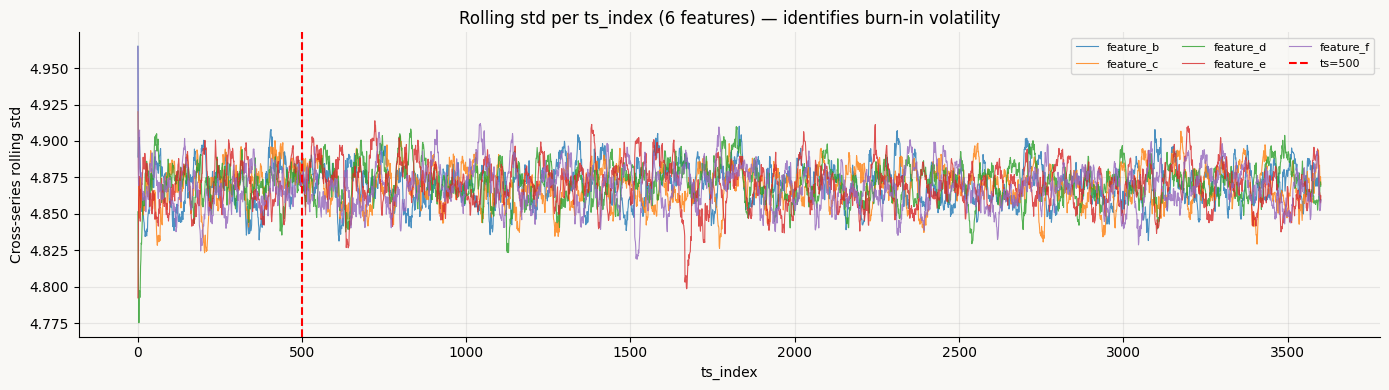

In [34]:
BURNIN_THRESHOLD = 500

fig, ax = plt.subplots(figsize=(14, 4))
for col in num_features[1:6]:
    roll_std = df.groupby(TS_COL)[col].std().rolling(20, min_periods=1).mean()
    roll_std.plot(ax=ax, lw=0.8, label=col, alpha=0.8)

ax.axvline(BURNIN_THRESHOLD, color="red", ls="--", lw=1.5, label=f"ts={BURNIN_THRESHOLD}")
ax.set_title("Rolling std per ts_index (6 features) — identifies burn-in volatility")
ax.set_xlabel("ts_index")
ax.set_ylabel("Cross-series rolling std")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

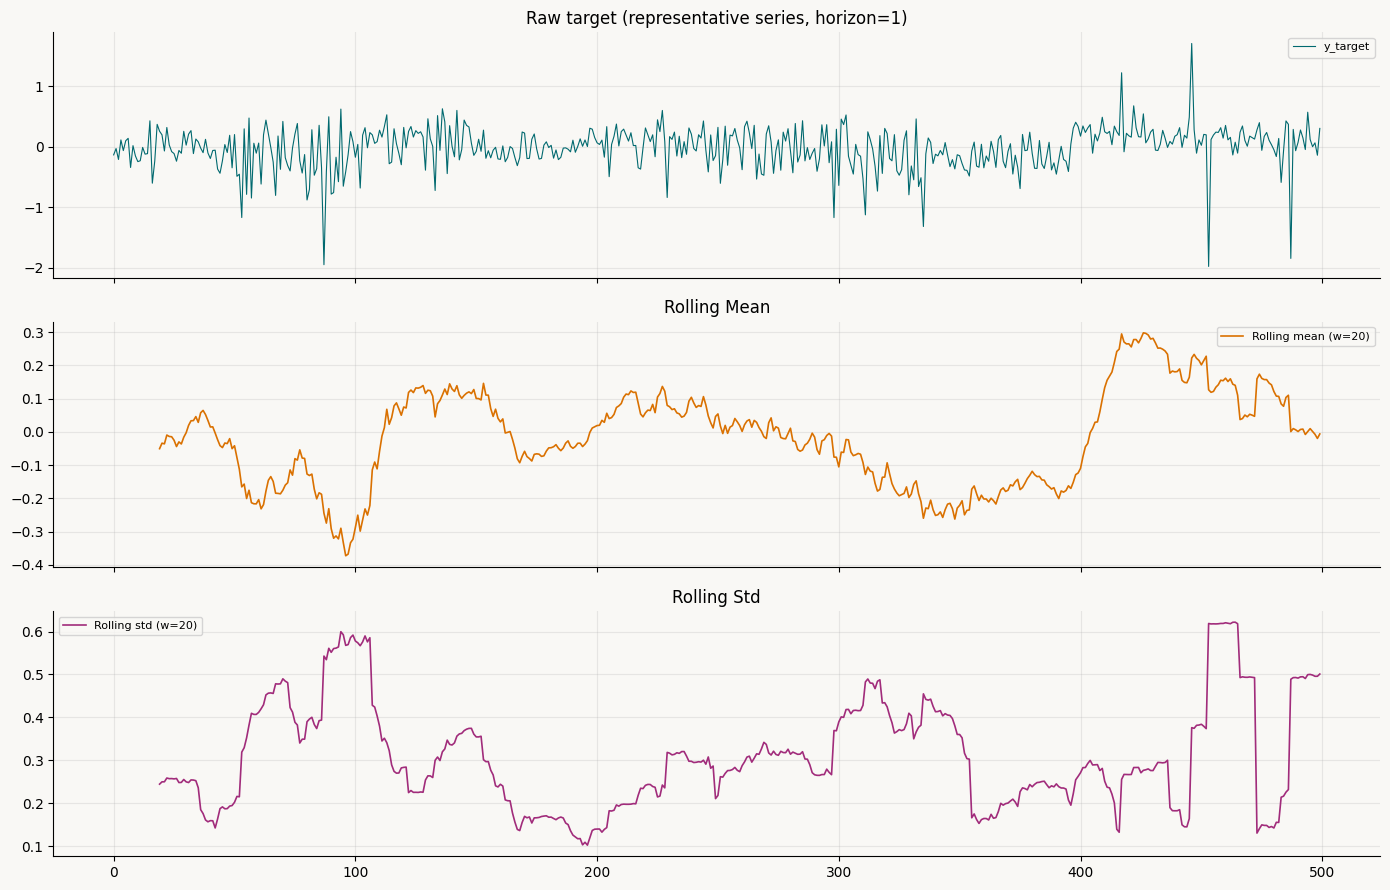

In [12]:
rep = df[(df["code"] == df["code"].value_counts().idxmax()) &
         (df[HORIZON_COL] == 1)].sort_values(TS_COL).head(500)

y = rep[TARGET].values

roll_mean = pd.Series(y).rolling(20).mean()
roll_std  = pd.Series(y).rolling(20).std()

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(y, color=TEAL, lw=0.8, label="y_target")
axes[0].set_title("Raw target (representative series, horizon=1)")
axes[1].plot(roll_mean, color=ORANGE, lw=1.2, label="Rolling mean (w=20)")
axes[1].set_title("Rolling Mean")
axes[2].plot(roll_std, color=MAROON, lw=1.2, label="Rolling std (w=20)")
axes[2].set_title("Rolling Std")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

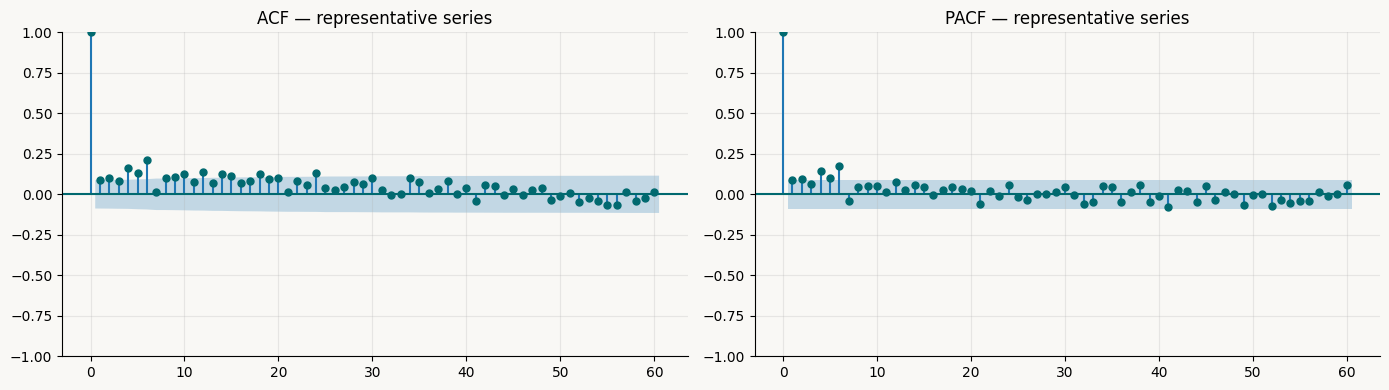

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf (y, lags=60, ax=axes[0], color=TEAL, title="ACF — representative series")
plot_pacf(y, lags=60, ax=axes[1], color=TEAL, title="PACF — representative series",
          method="ywm")
plt.tight_layout()
plt.show()

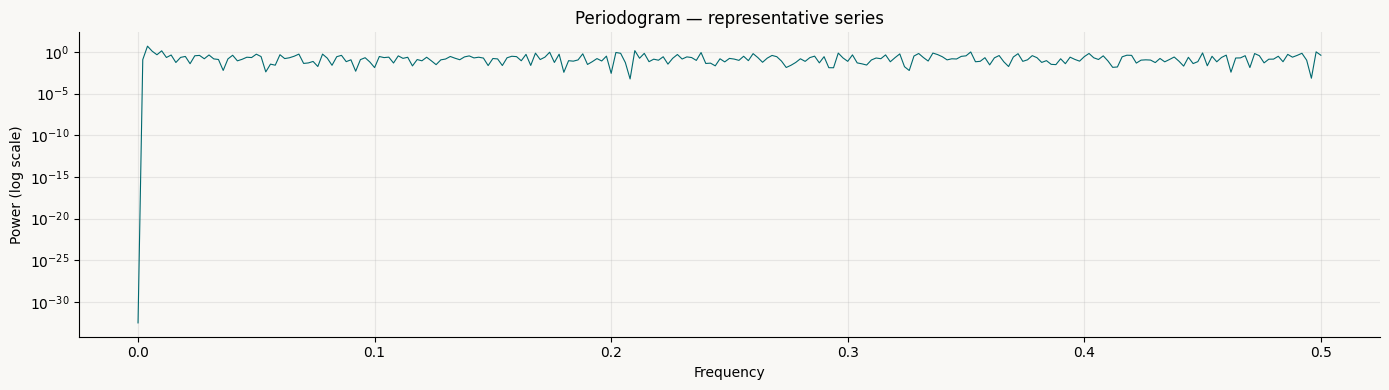

In [14]:
freqs, power = periodogram(y)

fig, ax = plt.subplots(figsize=(14, 4))
ax.semilogy(freqs, power, color=TEAL, lw=0.8)
ax.set_title("Periodogram — representative series")
ax.set_xlabel("Frequency")
ax.set_ylabel("Power (log scale)")
plt.tight_layout()
plt.show()

In [15]:
feat_stats = pd.concat([
    df[num_features].mean().rename("mean"),
    df[num_features].std().rename("std"),
    df[num_features].min().rename("min"),
    df[num_features].max().rename("max"),
    df[num_features].skew().rename("skew"),
    df[num_features].kurt().rename("kurtosis"),
    (df[num_features].isnull().mean() * 100).round(2).rename("missing_%"),
], axis=1).sort_values("kurtosis", ascending=False)

print(feat_stats.head(20).to_string())

                    mean            std         min           max       skew     kurtosis  missing_%
feature_bi     22.208468     378.650536    0.000000  6.606322e+04  77.866551  9230.449473       2.76
feature_ak      0.164434       0.343020    0.000000  2.839225e+01  19.218253   849.802230       0.15
feature_ag      1.233680       9.856426    0.000000  7.713116e+02  22.004661   801.122887       0.15
feature_ba  45269.657835  361102.290692    0.000000  3.175448e+07  22.717496   764.300902       0.00
feature_by     -0.081210       0.317121  -30.223029 -1.679419e-09 -16.244299   592.411574      11.02
feature_aa      0.425317       1.164690    0.000000  1.059639e+02  11.337627   408.666732       0.12
feature_bc  15129.287051   63637.977690    0.000000  5.542532e+06  12.984227   322.613230       0.00
feature_p       0.159498       0.444224    0.000000  2.720338e+01  11.515190   314.565946       0.12
feature_o       1.056751       7.293216    0.000000  3.687869e+02  13.863259   295.163513  

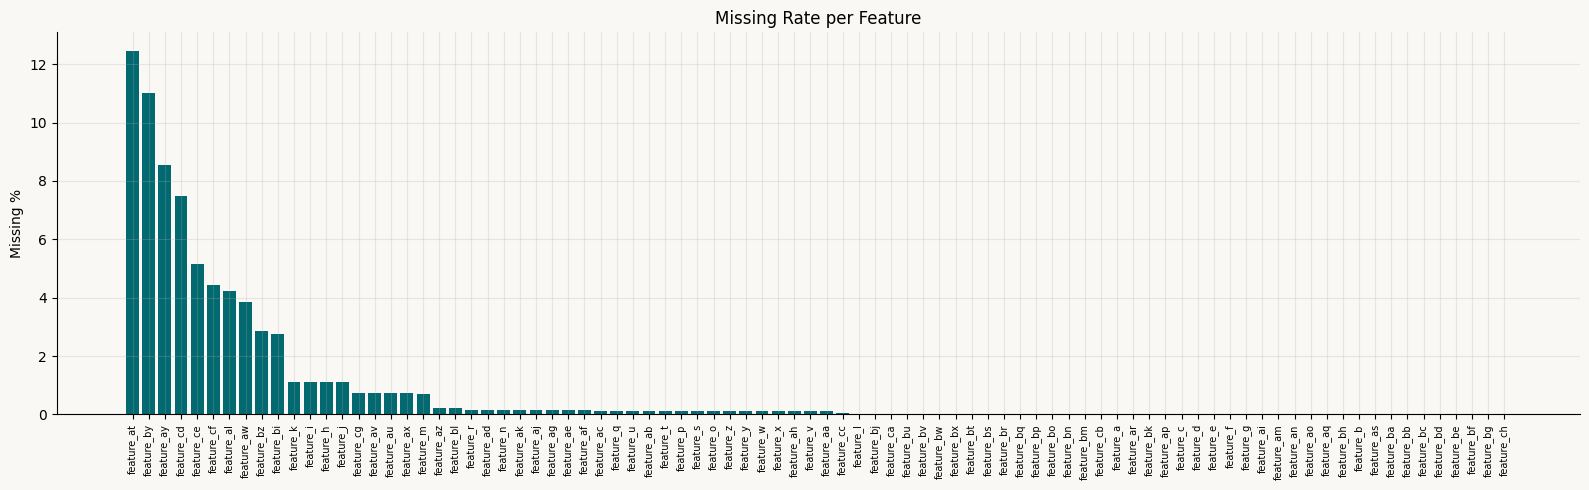

In [16]:
miss_pct = df[num_features].isnull().mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(range(len(miss_pct)), miss_pct.values * 100, color=TEAL)
ax.set_xticks(range(len(miss_pct)))
ax.set_xticklabels(miss_pct.index, rotation=90, fontsize=7)
ax.set_ylabel("Missing %")
ax.set_title("Missing Rate per Feature")
plt.tight_layout()
plt.show()

Features with excess kurtosis > 50: 38
                 skew     kurtosis
feature_bi  77.866551  9230.449473
feature_ak  19.218253   849.802230
feature_ag  22.004661   801.122887
feature_ba  22.717496   764.300902
feature_by -16.244299   592.411574
feature_aa  11.337627   408.666732
feature_bc  12.984227   322.613230
feature_p   11.515190   314.565946
feature_o   13.863259   295.163513
feature_ca -10.578925   289.721080
feature_az  12.319453   286.108868
feature_bz -11.505453   283.469352
feature_al   4.439157   260.116793
feature_cd -10.442901   251.066772
feature_bb  12.367654   248.206391
feature_cc  -9.336052   232.630914
feature_ce  -8.383373   232.346714
feature_bk   8.692612   213.439237
feature_au  11.276729   207.459236
feature_q   10.198706   179.447281


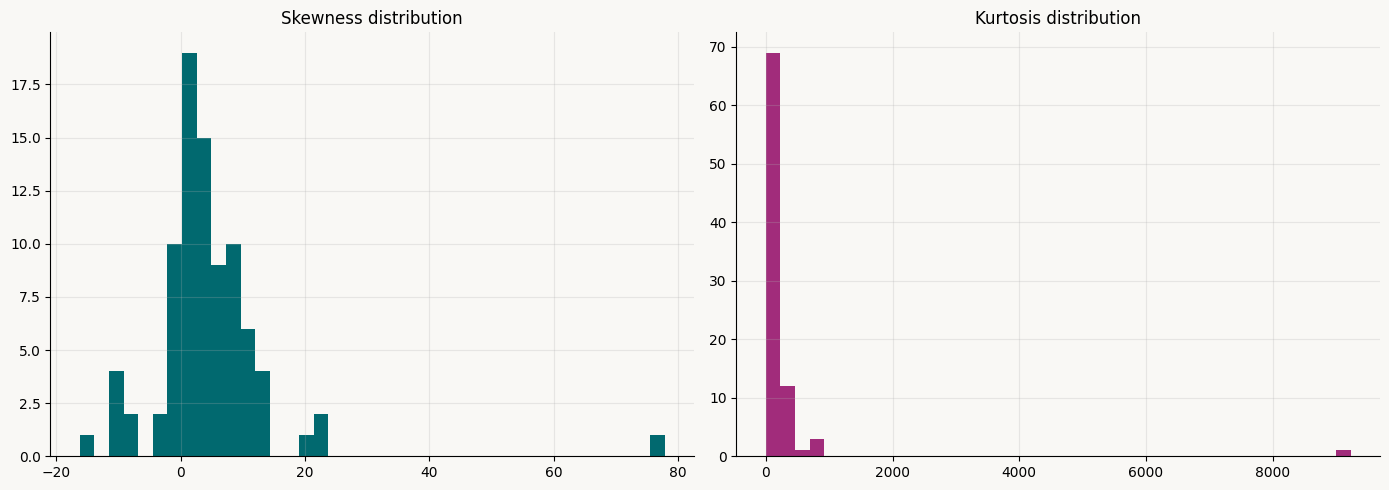

In [17]:
skew_kurt = pd.DataFrame({
    "skew"    : df[num_features].skew(),
    "kurtosis": df[num_features].kurt(),
}).sort_values("kurtosis", ascending=False)

flagged = skew_kurt[skew_kurt["kurtosis"] > 50]
print(f"Features with excess kurtosis > 50: {len(flagged)}")
print(flagged.head(20).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(skew_kurt["skew"],     bins=40, color=TEAL);   axes[0].set_title("Skewness distribution")
axes[1].hist(skew_kurt["kurtosis"], bins=40, color=MAROON); axes[1].set_title("Kurtosis distribution")
plt.tight_layout()
plt.show()

Feature: feature_bi
count: 5189982
mean: 22.208467622904987
std: 378.6505361247314
min: 0.0
max: 66063.21557497887
skew: 77.86655110838339
kurtosis: 9230.449473349627
pct_zero: 5.401964785234322
pct_near_zero: 5.4054330053553175


count    5.189982e+06
mean     2.220847e+01
std      3.786505e+02
min      0.000000e+00
1%       0.000000e+00
5%       0.000000e+00
25%      1.792965e-01
50%      5.875497e-01
75%      8.098222e+00
95%      3.932133e+01
99%      2.170649e+02
max      6.606322e+04
Name: feature_bi, dtype: float64

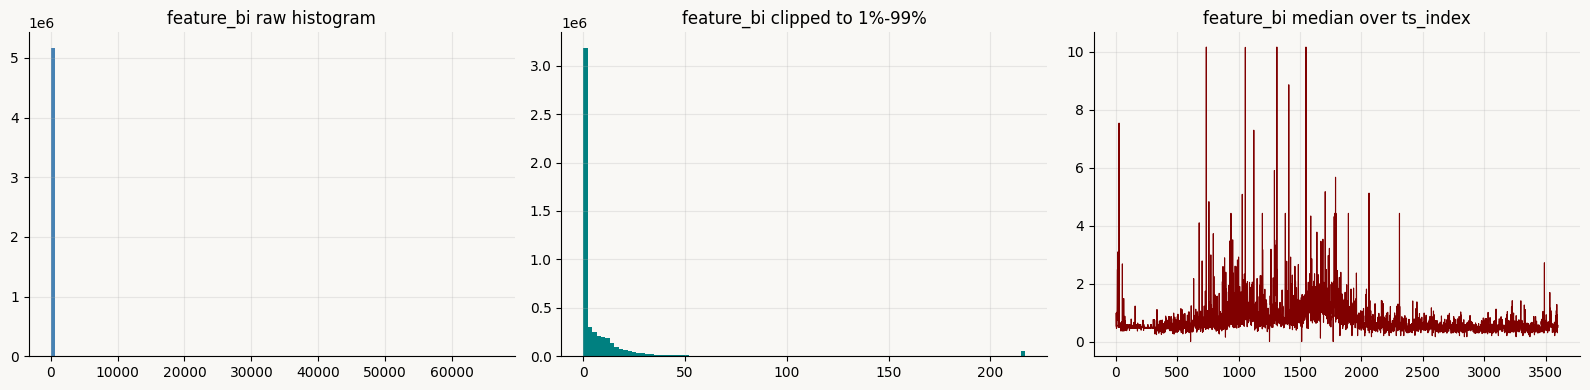

In [11]:
col = "feature_bi"

s = df[col].dropna()

print("Feature:", col)
print("count:", len(s))
print("mean:", s.mean())
print("std:", s.std())
print("min:", s.min())
print("max:", s.max())
print("skew:", s.skew())
print("kurtosis:", s.kurtosis())
print("pct_zero:", (s == 0).mean() * 100)
print("pct_near_zero:", (s.abs() < 1e-4).mean() * 100)

display(s.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# raw histogram
axes[0].hist(s, bins=100, color="steelblue")
axes[0].set_title(f"{col} raw histogram")

# clipped histogram for visibility
low, high = s.quantile(0.01), s.quantile(0.99)
axes[1].hist(s.clip(low, high), bins=100, color="teal")
axes[1].set_title(f"{col} clipped to 1%-99%")

# median over time
med = df.groupby("ts_index")[col].median()
axes[2].plot(med.index, med.values, color="maroon", lw=0.8)
axes[2].set_title(f"{col} median over ts_index")

plt.tight_layout()
plt.show()


In [12]:
df["feature_bi_log"] = np.log1p(df["feature_bi"])


In [13]:
cols_to_check = ["feature_bi", "feature_bi_log"]

rows = []
for c in cols_to_check:
    s = df[c].dropna()
    tmp = df[[c, "y_target"]].dropna()

    rows.append({
        "feature": c,
        "mean": s.mean(),
        "std": s.std(),
        "min": s.min(),
        "median": s.median(),
        "max": s.max(),
        "skew": s.skew(),
        "kurtosis": s.kurtosis(),
        "abs_corr_with_y": abs(tmp[c].corr(tmp["y_target"])),
    })

compare_bi = pd.DataFrame(rows)
display(compare_bi.round(4))


,feature,mean,std,min,median,max,skew,kurtosis,abs_corr_with_y
0,feature_bi,22.2085,378.6505,0.0,0.5875,66063.2156,77.8666,9230.4495,0.0005
1,feature_bi_log,1.2055,1.3560,0.0,0.4622,11.0984,1.3495,1.9601,0.0083


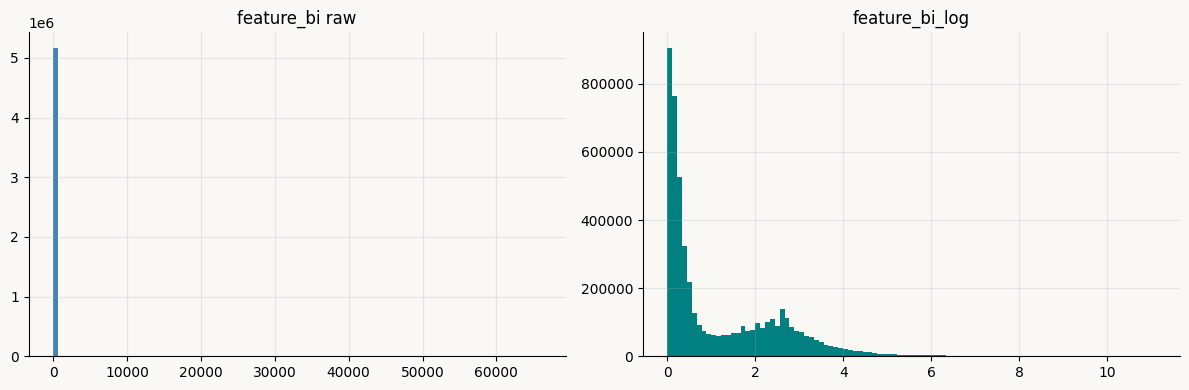

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["feature_bi"].dropna(), bins=100, color="steelblue")
axes[0].set_title("feature_bi raw")

axes[1].hist(df["feature_bi_log"].dropna(), bins=100, color="teal")
axes[1].set_title("feature_bi_log")

plt.tight_layout()
plt.show()


In [16]:
top8        = skew_kurt.nlargest(8, "kurtosis").index.tolist()
WINSOR_LO   = 0.01
WINSOR_HI   = 0.99

fig, axes = plt.subplots(8, 3, figsize=(18, 28))
fig.suptitle("Before | After Winsorisation | After Yeo-Johnson — Top 8 kurtosis",
             fontsize=13, y=1.001)

for i, col in enumerate(top8):
    sraw  = df[col].dropna()
    lo, hi = sraw.quantile(WINSOR_LO), sraw.quantile(WINSOR_HI)
    swins = sraw.clip(lo, hi)
    pt    = PowerTransformer(method="yeo-johnson", standardize=True)
    syj   = pd.Series(pt.fit_transform(swins.values.reshape(-1, 1)).flatten(), name=col)

    def _plot(ax, data, title, color):
        clipped = data.clip(data.quantile(0.001), data.quantile(0.999))
        clipped.plot.kde(ax=ax, color=color, lw=2)
        ax.set_title(f"{col} | {title}\nskew={data.skew():.2f} kurt={data.kurtosis():.1f}",
                     fontsize=8)
        ax.set_xlabel("")
        ax.yaxis.set_major_formatter(mticker.NullFormatter())

    _plot(axes[i, 0], sraw,  "RAW",                  MAROON)
    _plot(axes[i, 1], swins, f"Winsorised {int(WINSOR_LO*100)}-{int(WINSOR_HI*100)}th pct", ORANGE)
    _plot(axes[i, 2], syj,   "Yeo-Johnson",           TEAL)

plt.tight_layout()
plt.show()

NameError: name 'skew_kurt' is not defined

In [19]:
WINSOR_LO, WINSOR_HI = 0.01, 0.99
results = []

for col in skew_kurt.index:
    sraw      = df[col].dropna()
    lo, hi    = sraw.quantile(WINSOR_LO), sraw.quantile(WINSOR_HI)
    swins     = sraw.clip(lo, hi)
    pt        = PowerTransformer(method="yeo-johnson", standardize=True)
    syj       = pd.Series(pt.fit_transform(swins.values.reshape(-1, 1)).flatten())
    qt        = QuantileTransformer(output_distribution="normal", random_state=SEED)
    sqt       = pd.Series(qt.fit_transform(swins.values.reshape(-1, 1)).flatten())

    results.append({
        "feature"        : col,
        "skew_raw"       : round(sraw.skew(), 2),
        "kurt_raw"       : round(sraw.kurtosis(), 1),
        "kurt_after_yj"  : round(syj.kurtosis(), 1),
        "kurt_after_qt"  : round(sqt.kurtosis(), 1),
        "yj_lambda"      : round(pt.lambdas_[0], 4),
        "recommended"    : "quantile-normal" if syj.kurtosis() > 10 else "yeo-johnson",
    })

result_df = pd.DataFrame(results).sort_values("kurt_raw", ascending=False)
still_bad  = result_df[result_df["kurt_after_yj"] > 10]
print(f"Features still extreme (kurtosis > 10) after Yeo-Johnson: {len(still_bad)}")
print(still_bad[["feature", "kurt_raw", "kurt_after_yj", "kurt_after_qt", "recommended"]].to_string(index=False))
print("\nFull transformation plan (top 30):")
print(result_df.head(30)[["feature", "kurt_raw", "kurt_after_yj", "recommended", "yj_lambda"]].to_string(index=False))

Features still extreme (kurtosis > 10) after Yeo-Johnson: 2
   feature  kurt_raw  kurt_after_yj  kurt_after_qt     recommended
feature_al     260.1           15.9            5.4 quantile-normal
 feature_n     156.9           14.4            5.6 quantile-normal

Full transformation plan (top 30):
   feature  kurt_raw  kurt_after_yj     recommended  yj_lambda
feature_bi    9230.4           -1.4     yeo-johnson    -0.5539
feature_ak     849.8           -1.1     yeo-johnson    -5.0653
feature_ag     801.1            2.7     yeo-johnson    -4.8932
feature_ba     764.3           -1.2     yeo-johnson    -0.0234
feature_by     592.4           -0.1     yeo-johnson    16.1674
feature_aa     408.7           -1.0     yeo-johnson    -3.0779
feature_bc     322.6           -1.4     yeo-johnson    -0.0567
 feature_p     314.6           -0.7     yeo-johnson    -7.3218
 feature_o     295.2            2.1     yeo-johnson    -4.8287
feature_ca     289.7            0.3     yeo-johnson     7.5368
feature_az

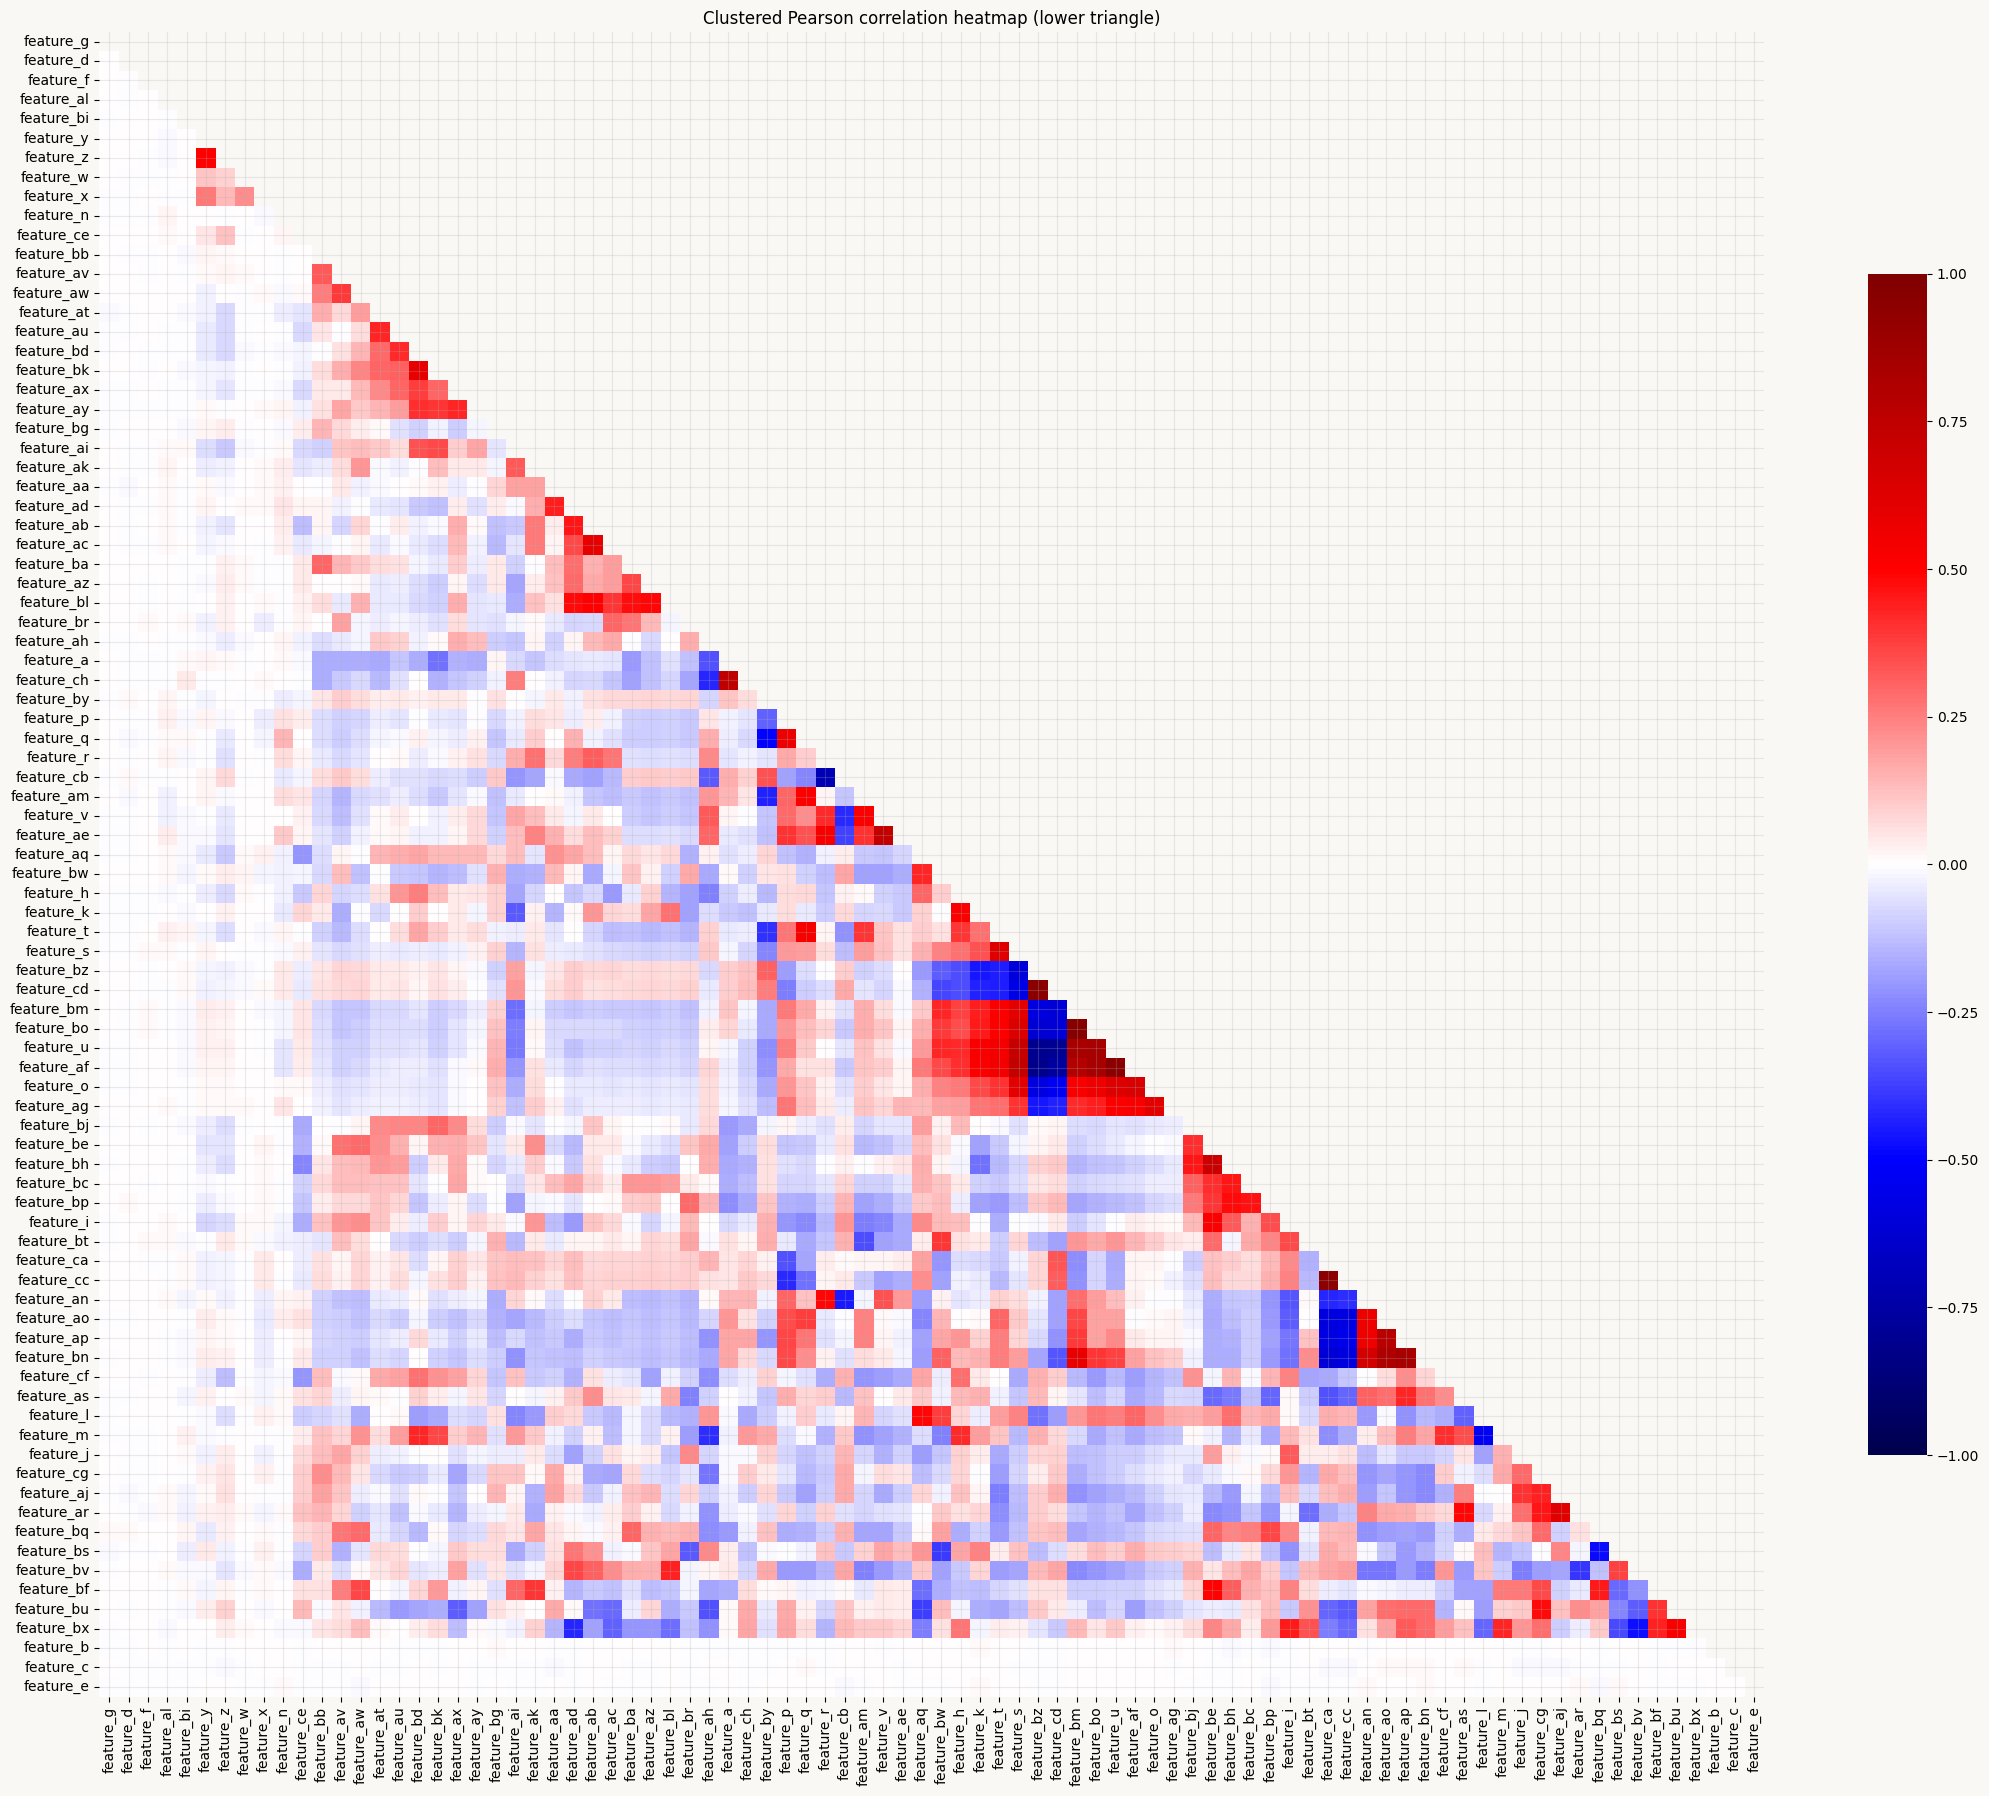

Pairs with |Pearson r| > 0.95: 4
     feat1      feat2  pearson_r    abs_r
feature_bm feature_bo   0.969736 0.969736
 feature_u feature_af   0.957092 0.957092
feature_bz feature_cd   0.953416 0.953416
feature_ca feature_cc   0.951648 0.951648


In [17]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

df_s = df[num_features].dropna().sample(min(50_000, len(df)), random_state=SEED)
pearson_mat = df_s.corr(method="pearson")

dist_arr = (1 - pearson_mat.abs().clip(0, 1)).to_numpy().copy()
np.fill_diagonal(dist_arr, 0)
link  = linkage(squareform(dist_arr.clip(0)), method="average")
order = dendrogram(link, no_plot=True)["leaves"]
p_ord = pearson_mat.iloc[order, order]

fig, ax = plt.subplots(figsize=(22, 20))
mask = np.triu(np.ones_like(p_ord, dtype=bool))
sns.heatmap(p_ord, mask=mask, cmap="seismic", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0, ax=ax, cbar_kws={"shrink": 0.6})
ax.set_title("Clustered Pearson correlation heatmap (lower triangle)", fontsize=12)
plt.tight_layout()
plt.show()

upper   = pearson_mat.where(np.triu(np.ones(pearson_mat.shape, dtype=bool), k=1))
hi_corr = (upper.stack()
                .reset_index()
                .rename(columns={"level_0": "feat1", "level_1": "feat2", 0: "pearson_r"})
                .assign(abs_r=lambda x: x["pearson_r"].abs())
                .sort_values("abs_r", ascending=False))
flagged_pairs = hi_corr[hi_corr["abs_r"] > 0.95]
print(f"Pairs with |Pearson r| > 0.95: {len(flagged_pairs)}")
print(flagged_pairs.head(10).to_string(index=False))

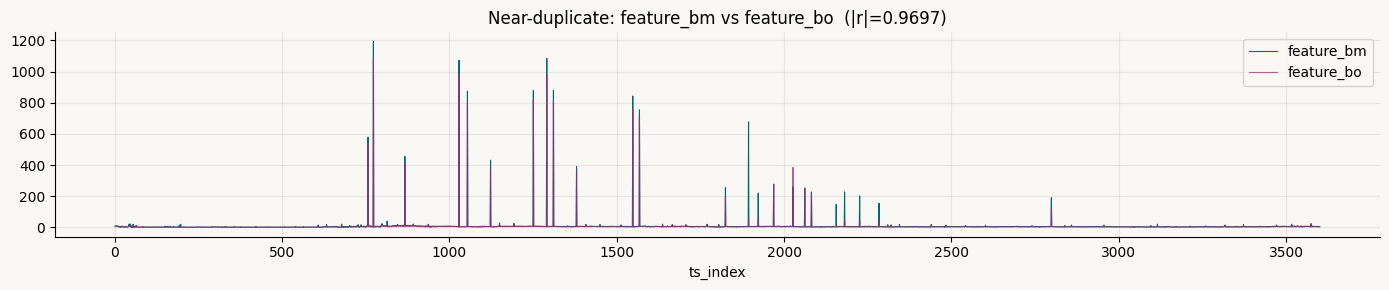

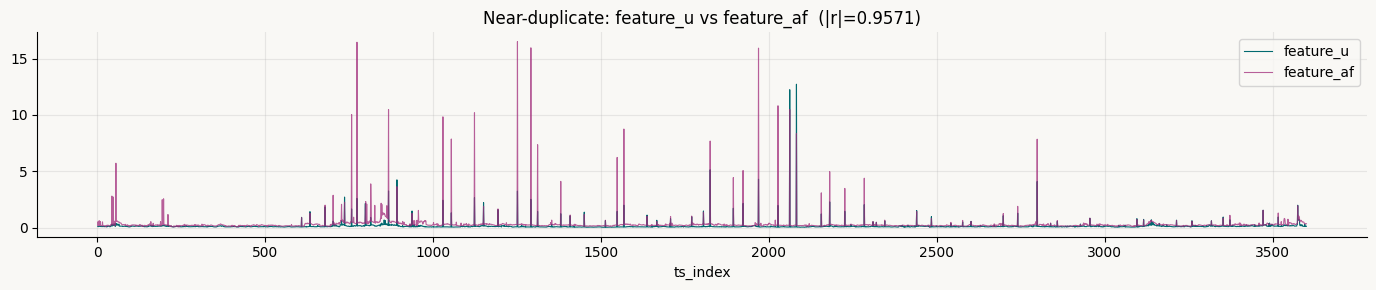

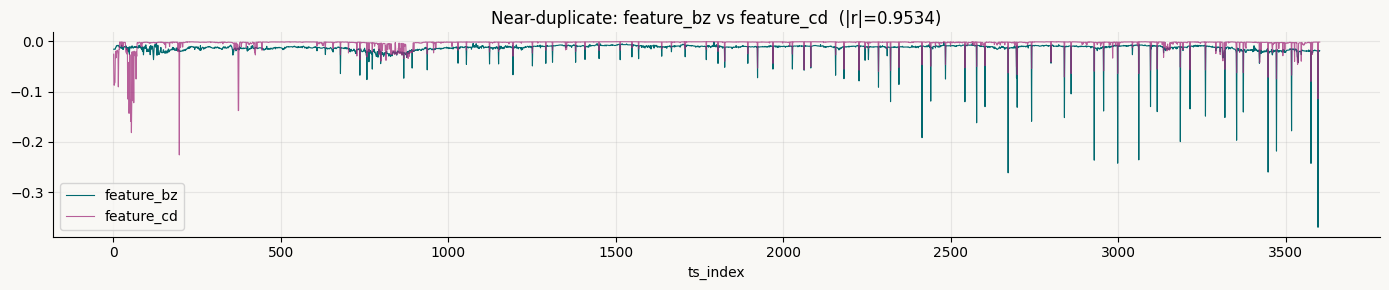

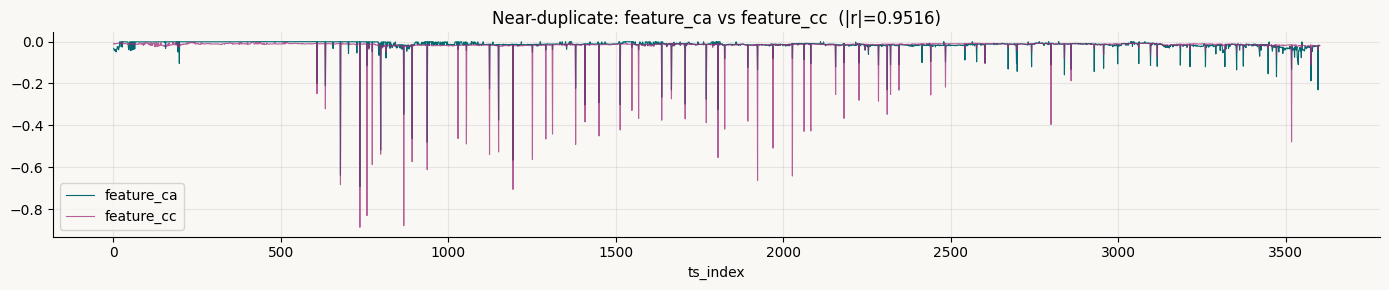

In [21]:
top_pairs = flagged_pairs.head(5)

for _, row in top_pairs.iterrows():
    c1, c2 = row["feat1"], row["feat2"]
    med1 = df.groupby(TS_COL)[c1].median()
    med2 = df.groupby(TS_COL)[c2].median()

    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(med1.index, med1.values, lw=0.8, label=c1, color=TEAL)
    ax.plot(med2.index, med2.values, lw=0.8, label=c2, color=MAROON, alpha=0.75)
    ax.set_title(f"Near-duplicate: {c1} vs {c2}  (|r|={row['abs_r']:.4f})")
    ax.set_xlabel("ts_index")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [20]:
pairs = [
    ("feature_bm", "feature_bo"),
    ("feature_u", "feature_af"),
    ("feature_bz", "feature_cd"),
    ("feature_ca", "feature_cc"),
]

rows = []
for f1, f2 in pairs:
    for c in [f1, f2]:
        tmp = df[[c, "y_target"]].dropna()
        rows.append({
            "pair": f"{f1} vs {f2}",
            "feature": c,
            "missing": df[c].isna().sum(),
            "missing_pct": 100 * df[c].isna().mean(),
            "abs_corr_with_y": abs(tmp[c].corr(tmp["y_target"])),
            "skew": df[c].dropna().skew(),
            "kurtosis": df[c].dropna().kurtosis()
        })

pair_compare = pd.DataFrame(rows)
display(pair_compare.round(4))

,pair,feature,missing,missing_pct,abs_corr_with_y,skew,kurtosis
0,feature_bm vs feature_bo,feature_bm,0,0.0000,0.0546,4.5844,23.2763
1,feature_bm vs feature_bo,feature_bo,0,0.0000,0.0582,5.2675,29.6994
2,feature_u vs feature_af,feature_u,7122,0.1334,0.0701,5.7171,37.8265
3,feature_u vs feature_af,feature_af,8126,0.1522,0.0735,6.0574,41.3605
4,feature_bz vs feature_cd,feature_bz,151722,2.8426,0.0905,-11.5055,283.4694
5,feature_bz vs feature_cd,feature_cd,400114,7.4964,0.0860,-10.4429,251.0668
6,feature_ca vs feature_cc,feature_ca,40,0.0007,0.0050,-10.5789,289.7211
7,feature_ca vs feature_cc,feature_cc,2635,0.0494,0.0170,-9.3361,232.6309


Recommanded drop list based on previous results

In [ ]:
drop_cols = ["feature_bo", "feature_af", "feature_cd", "feature_ca"]

Top 10 most correlated feature pairs:
 feature_1  feature_2  similarity
feature_bm feature_bo    0.971266
 feature_u feature_af    0.956758
feature_bz feature_cd    0.953494
feature_ca feature_cc    0.938278
feature_af feature_bz    0.846458
feature_af feature_bo    0.838575
 feature_u feature_bz    0.836433
 feature_u feature_bo    0.836048
 feature_u feature_bm    0.833292
 feature_u feature_cd    0.832444

Top 10 least correlated feature pairs:
 feature_1  feature_2  similarity
feature_ch feature_by         NaN
feature_ch feature_bz         NaN
feature_ch feature_ca         NaN
feature_ch feature_cb         NaN
feature_ch feature_cc         NaN
feature_ch feature_cd         NaN
feature_ch feature_ce         NaN
feature_ch feature_cf         NaN
feature_ch feature_cg         NaN
feature_ch feature_ch         NaN


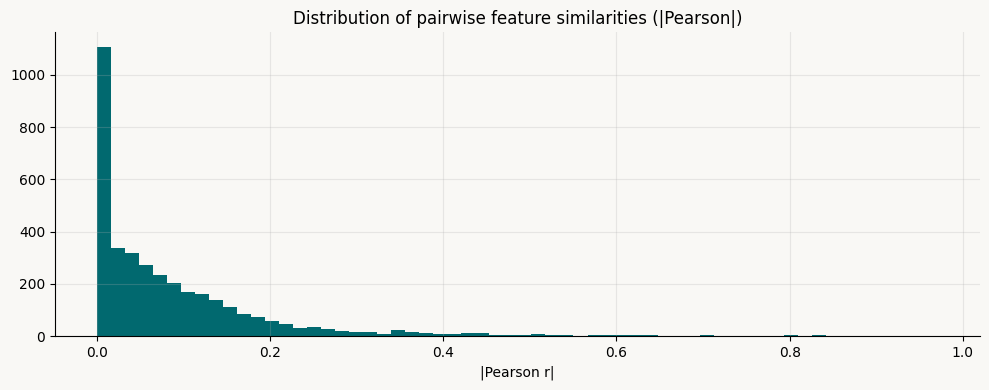

In [22]:
sample_df = df[num_features].dropna(how="all").sample(min(50_000, len(df)), random_state=SEED)
corr_all  = sample_df.corr().abs()

pairs = (corr_all.where(np.triu(np.ones(corr_all.shape), k=1).astype(bool))
                 .stack()
                 .reset_index())
pairs.columns = ["feature_1", "feature_2", "similarity"]
pairs = pairs.sort_values("similarity", ascending=False)

print("Top 10 most correlated feature pairs:")
print(pairs.head(10).to_string(index=False))
print("\nTop 10 least correlated feature pairs:")
print(pairs.tail(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(pairs["similarity"], bins=60, color=TEAL)
ax.set_title("Distribution of pairwise feature similarities (|Pearson|)")
ax.set_xlabel("|Pearson r|")
plt.tight_layout()
plt.show()

Top 15 features by |correlation with target|:
feature_bz    0.087380
feature_cd    0.082413
feature_af    0.073541
feature_u     0.070688
feature_bo    0.059675
feature_s     0.055934
feature_bm    0.055625
feature_t     0.038330
feature_o     0.037441
feature_am    0.035122
feature_ag    0.034436
feature_al    0.030706
feature_k     0.030692
feature_v     0.029876
feature_n     0.029310


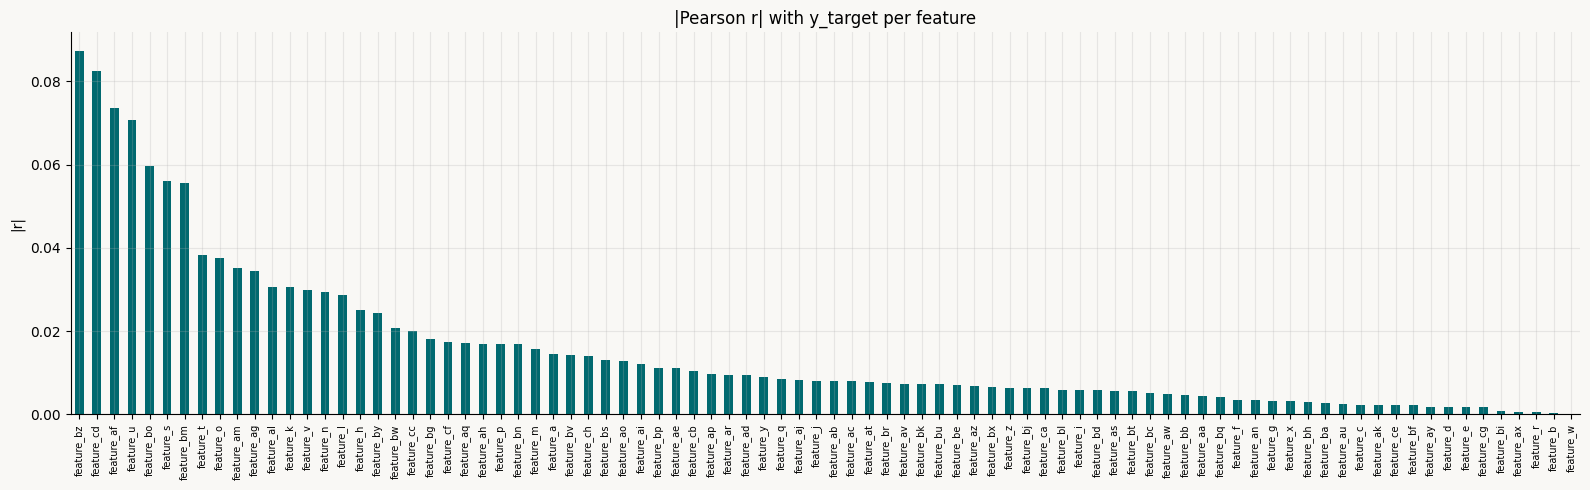

In [23]:
feat_target_corr = (df[num_features + [TARGET]]
                    .sample(min(100_000, len(df)), random_state=SEED)
                    .corr()[TARGET]
                    .drop(TARGET)
                    .abs()
                    .sort_values(ascending=False))

print("Top 15 features by |correlation with target|:")
print(feat_target_corr.head(15).to_string())

fig, ax = plt.subplots(figsize=(16, 5))
feat_target_corr.plot.bar(ax=ax, color=TEAL)
ax.set_title("|Pearson r| with y_target per feature")
ax.set_ylabel("|r|")
ax.tick_params(axis="x", labelsize=7)
plt.tight_layout()
plt.show()

Top 20 features by mean absolute IC across horizons:
horizon            1         3        10        25  mean_abs_IC
feature_bz  0.088260  0.087607  0.109422  0.132854     0.104536
feature_ca  0.087326  0.086319  0.105416  0.128304     0.101841
feature_by  0.088254  0.084886  0.103966  0.127336     0.101110
feature_am -0.084260 -0.080415 -0.100280 -0.129186     0.098535
feature_u  -0.085031 -0.082714 -0.100421 -0.124492     0.098165
feature_cc  0.081885  0.081226  0.099738  0.123649     0.096625
feature_cd  0.080968  0.081053  0.099292  0.117919     0.094808
feature_ao -0.079232 -0.076852 -0.096608 -0.123820     0.094128
feature_az  0.078130  0.077575  0.095643  0.120048     0.092849
feature_cb  0.078677  0.077577  0.094159  0.117240     0.091913
feature_bq  0.077112  0.076221  0.093892  0.116738     0.090991
feature_ap -0.074820 -0.074404 -0.093250 -0.117161     0.089909
feature_br  0.074045  0.073917  0.092563  0.115749     0.089069
feature_af -0.076695 -0.075143 -0.090580 -0.112945 

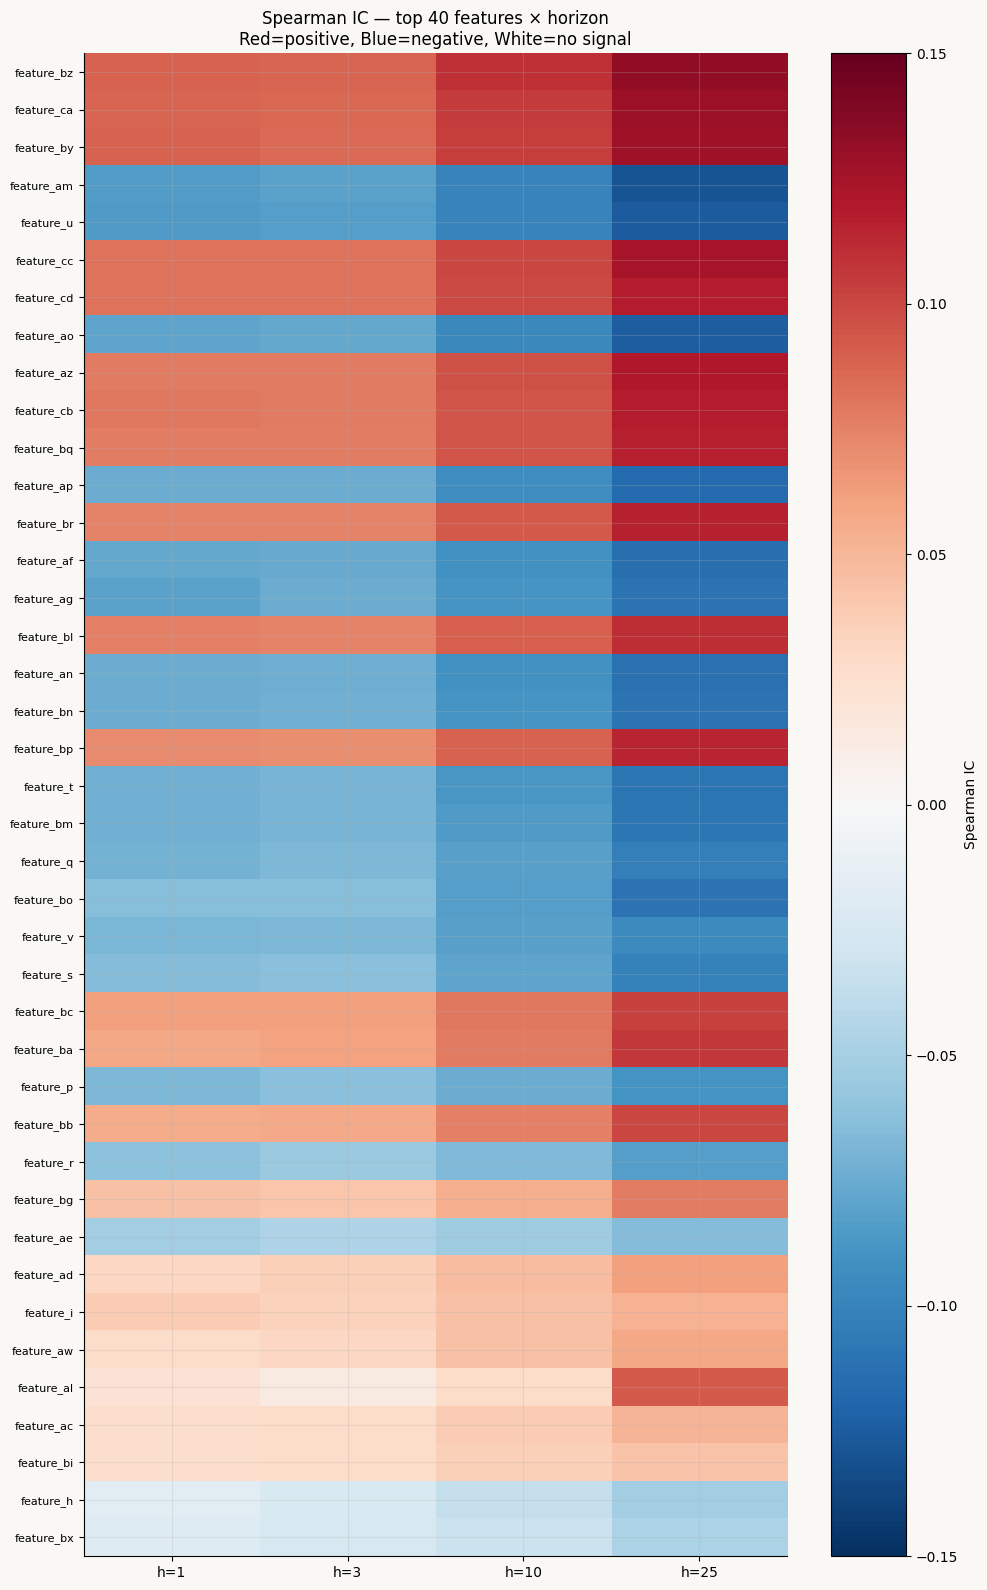

In [23]:
from scipy.stats import spearmanr

ic_rows = []
for h in horizons:
    sub = df[df[HORIZON_COL] == h][num_features + [TARGET]].dropna()
    row = {"horizon": h}
    for col in num_features:
        r, _ = spearmanr(sub[col], sub[TARGET])
        row[col] = r
    ic_rows.append(row)

ic_df = pd.DataFrame(ic_rows).set_index("horizon").T
ic_df["mean_abs_IC"] = ic_df.abs().mean(axis=1)
ic_df = ic_df.sort_values("mean_abs_IC", ascending=False)

print("Top 20 features by mean absolute IC across horizons:")
print(ic_df.head(20).to_string())

fig, ax = plt.subplots(figsize=(10, 16))
plot_data = ic_df.drop(columns="mean_abs_IC").head(40)
im = ax.imshow(plot_data.values, aspect="auto", cmap="RdBu_r", vmin=-0.15, vmax=0.15)
ax.set_xticks(range(len(horizons)))
ax.set_xticklabels([f"h={h}" for h in horizons])
ax.set_yticks(range(40))
ax.set_yticklabels(plot_data.index, fontsize=8)
plt.colorbar(im, ax=ax, label="Spearman IC")
ax.set_title("Spearman IC — top 40 features × horizon\nRed=positive, Blue=negative, White=no signal")
plt.tight_layout()
plt.show()

In [25]:
hvals = sorted(df[HORIZON_COL].dropna().unique())

rows = []

for col in num_features:
    vals = []
    for h in hvals:
        tmp = df.loc[df[HORIZON_COL] == h, [col, TARGET]].dropna()
        vals.append(abs(spearmanr(tmp[col], tmp[TARGET]).statistic) if len(tmp) >= 5 else np.nan)

    valid = np.isfinite(vals)

    rows.append({
        "feature": col,
        "corr_horizon_vs_absIC": spearmanr(np.array(hvals)[valid], np.array(vals)[valid]).statistic if valid.sum() >= 3 else np.nan
    })

ic_trend_simple = pd.DataFrame(rows).sort_values("corr_horizon_vs_absIC", ascending=False)
display(ic_trend_simple.head(20).round(4))


,feature,corr_horizon_vs_absIC
0,feature_a,1.0
23,feature_x,1.0
26,feature_aa,1.0
27,feature_ab,1.0
28,feature_ac,1.0
29,feature_ad,1.0
34,feature_ai,1.0
36,feature_ak,1.0
44,feature_as,1.0
45,feature_at,1.0


In [25]:
from scipy.stats import spearmanr

def _safe_spearman(x, y):
    if len(x) < 3:
        return np.nan
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan
    r, _ = spearmanr(x, y, nan_policy="omit")
    return float(r) if np.isfinite(r) else np.nan

def consistent_relevance_thresholds(
    df,
    features,
    target_col=TARGET,
    ts_col=TS_COL,
    horizon_col=HORIZON_COL,
    n_bins=24,
    min_points=200,
    min_horizons=2,
    min_consecutive=3,
    sign_consistency_min=0.7,
    ic_floor=0.01,
    z_mad=2.0
):
    cols = [ts_col, horizon_col, target_col] + features
    work = df[cols].sort_values(ts_col).copy()

    q = np.linspace(0, 1, n_bins + 1)
    edges = np.unique(work[ts_col].quantile(q).to_numpy())
    if len(edges) < 4:
        raise ValueError("Not enough ts_index variation to create bins.")
    edges[0] = work[ts_col].min() - 1e-9
    edges[-1] = work[ts_col].max() + 1e-9

    work["__bin"] = pd.cut(work[ts_col], bins=edges, include_lowest=True, duplicates="drop")
    bin_levels = list(work["__bin"].cat.categories)
    horizons = sorted(work[horizon_col].dropna().unique().tolist())

    summary_rows = []
    detail = {}

    for feat in features:
        base = work[[ts_col, horizon_col, target_col, feat, "__bin"]].dropna(subset=[target_col, feat])
        if base.empty:
            summary_rows.append({
                "feature": feat,
                "threshold_ts": np.nan,
                "ic_threshold": np.nan,
                "status": "no_data",
                "n_bins_used": 0
            })
            detail[feat] = pd.DataFrame()
            continue

        rows = []
        for b in bin_levels:
            sub_b = base[base["__bin"] == b]
            if sub_b.empty:
                continue

            ic_vals = []
            signs = []
            for h in horizons:
                sh = sub_b[sub_b[horizon_col] == h]
                if len(sh) < min_points:
                    continue
                r = _safe_spearman(sh[feat].to_numpy(), sh[target_col].to_numpy())
                if np.isfinite(r):
                    ic_vals.append(r)
                    signs.append(np.sign(r))

            if len(ic_vals) >= min_horizons:
                signs_arr = np.array(signs)
                sign_consistency = max((signs_arr > 0).mean(), (signs_arr < 0).mean())
                rows.append({
                    "bin_start": float(b.left),
                    "bin_end": float(b.right),
                    "mean_ic": float(np.mean(ic_vals)),
                    "abs_ic": float(np.mean(np.abs(ic_vals))),
                    "sign_consistency": float(sign_consistency),
                    "n_horizons": int(len(ic_vals))
                })

        trace = pd.DataFrame(rows).sort_values("bin_start").reset_index(drop=True)
        detail[feat] = trace

        if len(trace) < min_consecutive:
            summary_rows.append({
                "feature": feat,
                "threshold_ts": np.nan,
                "ic_threshold": np.nan,
                "status": "insufficient_bins",
                "n_bins_used": int(len(trace))
            })
            continue

        early_n = max(min_consecutive, int(np.ceil(len(trace) * 0.4)))
        baseline = trace["abs_ic"].iloc[:early_n]
        med = float(baseline.median())
        mad = float((baseline - med).abs().median())
        robust_sigma = 1.4826 * mad
        ic_threshold = float(max(ic_floor, med + z_mad * robust_sigma))

        ok = (trace["abs_ic"] >= ic_threshold) & (trace["sign_consistency"] >= sign_consistency_min)

        start_idx = None
        for i in range(0, len(trace) - min_consecutive + 1):
            if ok.iloc[i:i + min_consecutive].all():
                start_idx = i
                break

        if start_idx is None:
            summary_rows.append({
                "feature": feat,
                "threshold_ts": np.nan,
                "ic_threshold": ic_threshold,
                "status": "never_consistent",
                "n_bins_used": int(len(trace))
            })
        else:
            summary_rows.append({
                "feature": feat,
                "threshold_ts": float(trace.loc[start_idx, "bin_start"]),
                "ic_threshold": ic_threshold,
                "status": "consistent_from_ts",
                "n_bins_used": int(len(trace))
            })

    summary = pd.DataFrame(summary_rows).sort_values(
        ["status", "threshold_ts"], na_position="last"
    ).reset_index(drop=True)

    return summary, detail

consistency_df, consistency_detail = consistent_relevance_thresholds(df, num_features)

print(consistency_df.head(30).to_string(index=False))
print("\nConsistent features:")
print(
    consistency_df[consistency_df["status"] == "consistent_from_ts"]
    .sort_values("threshold_ts")
    .head(30)
    .to_string(index=False)
)


   feature  threshold_ts  ic_threshold             status  n_bins_used
feature_bf         230.0      0.017983 consistent_from_ts           24
feature_bx         230.0      0.054162 consistent_from_ts           24
feature_ay        1606.0      0.019360 consistent_from_ts           24
feature_bj        1606.0      0.019783 consistent_from_ts           24
 feature_a           NaN      0.065236   never_consistent           24
 feature_b           NaN      0.010000   never_consistent           24
 feature_c           NaN      0.010000   never_consistent           24
 feature_d           NaN      0.010000   never_consistent           24
 feature_e           NaN      0.010000   never_consistent           24
 feature_f           NaN      0.010000   never_consistent           24
 feature_g           NaN      0.010000   never_consistent           24
 feature_h           NaN      0.112062   never_consistent           24
 feature_i           NaN      0.082715   never_consistent           24
 featu

   feature  threshold_ts  ic_threshold             status  n_bins_used  max_abs_ic selected_horizons  activation_ts             role
feature_au           NaN      0.035375   never_consistent           24    0.029136                []            NaN             drop
 feature_a           NaN      0.065236   never_consistent           24    0.029015                []            NaN             drop
feature_bw           NaN      0.055530   never_consistent           24    0.028633                []            NaN             drop
feature_ak           NaN      0.062413   never_consistent           24    0.027830                []            NaN             drop
feature_ax           NaN      0.033190   never_consistent           24    0.025892                []            NaN             drop
feature_bt           NaN      0.047151   never_consistent           24    0.025587                []            NaN             drop
feature_ab           NaN      0.038788   never_consistent           2

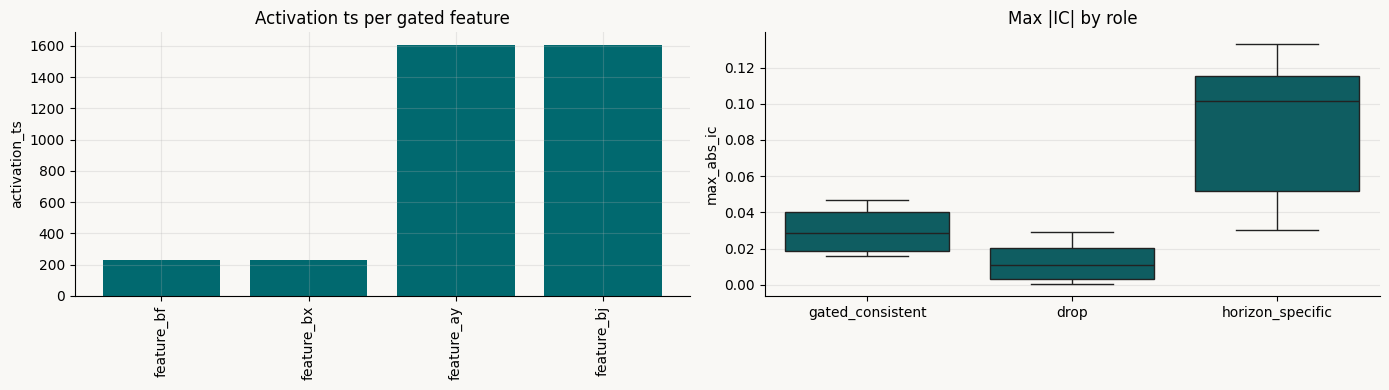

In [26]:
ic_mat = ic_df.drop(columns=["mean_abs_IC"], errors="ignore").copy()

max_abs_ic = ic_mat.abs().max(axis=1).rename("max_abs_ic")
selected_horizons = ic_mat.apply(
    lambda r: [int(h) for h, v in r.items() if pd.notna(v) and abs(v) >= 0.03],
    axis=1
).rename("selected_horizons")

feature_registry = consistency_df.merge(max_abs_ic, left_on="feature", right_index=True, how="left")
feature_registry = feature_registry.merge(selected_horizons, left_on="feature", right_index=True, how="left")
feature_registry["selected_horizons"] = feature_registry["selected_horizons"].apply(
    lambda x: x if isinstance(x, list) else []
)
feature_registry["activation_ts"] = feature_registry["threshold_ts"]

feature_registry["role"] = np.select(
    [
        feature_registry["status"].eq("consistent_from_ts"),
        feature_registry["max_abs_ic"].ge(0.03)
    ],
    [
        "gated_consistent",
        "horizon_specific"
    ],
    default="drop"
)

print(feature_registry.sort_values(["role", "activation_ts", "max_abs_ic"], ascending=[True, True, False]).to_string(index=False))

plot_df = feature_registry[feature_registry["role"] == "gated_consistent"].sort_values("activation_ts")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

if len(plot_df) > 0:
    axes[0].bar(plot_df["feature"], plot_df["activation_ts"], color=TEAL)
    axes[0].tick_params(axis="x", rotation=90)
else:
    axes[0].text(0.5, 0.5, "No gated features", ha="center", va="center")

axes[0].set_title("Activation ts per gated feature")
axes[0].set_ylabel("activation_ts")

sns.boxplot(data=feature_registry, x="role", y="max_abs_ic", ax=axes[1], color=TEAL)
axes[1].set_title("Max |IC| by role")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()


In [29]:
core_k = 15
support_k = 30
min_abs_ic = 0.01

ic_matrix = ic_df.drop(columns=["mean_abs_IC"], errors="ignore").copy()

ic_selection_table = ic_matrix.stack().reset_index()
ic_selection_table.columns = ["feature", "horizon", "ic_spearman"]

ic_selection_table["abs_ic"] = ic_selection_table["ic_spearman"].abs()
ic_selection_table["ic_sign"] = np.where(
    ic_selection_table["ic_spearman"] > 0,
    "positive",
    np.where(ic_selection_table["ic_spearman"] < 0, "negative", "zero")
)

ic_selection_table["rank_abs_ic_within_horizon"] = (
    ic_selection_table.groupby("horizon")["abs_ic"].rank(method="first", ascending=False)
)

ic_selection_table["is_selected_horizon_core"] = (
    (ic_selection_table["rank_abs_ic_within_horizon"] <= core_k) &
    (ic_selection_table["abs_ic"] >= min_abs_ic)
)

ic_selection_table["is_selected_horizon_support"] = (
    (ic_selection_table["rank_abs_ic_within_horizon"] <= support_k) &
    (ic_selection_table["rank_abs_ic_within_horizon"] > core_k) &
    (ic_selection_table["abs_ic"] >= min_abs_ic)
)

ic_selection_table["is_selected_horizon"] = (
    ic_selection_table["is_selected_horizon_core"] |
    ic_selection_table["is_selected_horizon_support"]
)

ic_selection_table["selection_tier"] = np.select(
    [
        ic_selection_table["is_selected_horizon_core"],
        ic_selection_table["is_selected_horizon_support"]
    ],
    ["core", "support"],
    default="not_selected"
)

selected = ic_selection_table[
    ic_selection_table["is_selected_horizon"]
].sort_values(["horizon", "rank_abs_ic_within_horizon"])

rows = []
for h, g in selected.groupby("horizon"):
    rows.append({
        "horizon": h,
        "n_core": int(g["is_selected_horizon_core"].sum()),
        "n_support": int(g["is_selected_horizon_support"].sum()),
        "core_features": ", ".join(g.loc[g["is_selected_horizon_core"], "feature"].astype(str).tolist()),
        "support_features": ", ".join(g.loc[g["is_selected_horizon_support"], "feature"].astype(str).tolist())
    })

ic_selection_by_horizon = pd.DataFrame(rows)
if not ic_selection_by_horizon.empty:
    ic_selection_by_horizon = ic_selection_by_horizon.sort_values("horizon").reset_index(drop=True)

best_idx = ic_selection_table.groupby("feature")["abs_ic"].idxmax()

feature_best_horizon = ic_selection_table.loc[
    best_idx, ["feature", "horizon", "ic_spearman", "abs_ic"]
].rename(columns={
    "horizon": "best_horizon",
    "ic_spearman": "best_horizon_ic",
    "abs_ic": "best_horizon_abs_ic"
})

selected_horizons = (
    selected.groupby("feature")["horizon"]
    .apply(lambda s: list(pd.unique(s)))
    .rename("selected_horizons")
)

feature_best_horizon = feature_best_horizon.merge(
    selected_horizons, on="feature", how="left"
)

feature_best_horizon["selected_horizons"] = feature_best_horizon["selected_horizons"].apply(
    lambda x: x if isinstance(x, list) else []
)

print("Per-horizon selected features")
if not ic_selection_by_horizon.empty:
    print(ic_selection_by_horizon.to_string(index=False))
else:
    print("No features selected.")

print("\nFeature-horizon selection table (top 120 rows)")
if not selected.empty:
    print(
        selected[
            [
                "feature",
                "horizon",
                "ic_spearman",
                "abs_ic",
                "rank_abs_ic_within_horizon",
                "ic_sign",
                "selection_tier"
            ]
        ].head(120).to_string(index=False)
    )
else:
    print("No selected feature-horizon pairs.")

print("\nBest horizon per feature")
print(
    feature_best_horizon.sort_values("best_horizon_abs_ic", ascending=False)
    .head(60)
    .to_string(index=False)
)

Per-horizon selected features
 horizon  n_core  n_support                                                                                                                                                                     core_features                                                                                                                                                              support_features
       1      15         15 feature_bz, feature_by, feature_ca, feature_u, feature_am, feature_cc, feature_cd, feature_ag, feature_ao, feature_cb, feature_az, feature_bq, feature_af, feature_bl, feature_ap  feature_an, feature_br, feature_bn, feature_bm, feature_t, feature_q, feature_bp, feature_v, feature_p, feature_s, feature_bo, feature_bc, feature_r, feature_ba, feature_bb
       3      15         15 feature_bz, feature_ca, feature_by, feature_u, feature_cc, feature_cd, feature_am, feature_cb, feature_az, feature_ao, feature_bq, feature_af, feature_ag, feature_bl, feature_ap  fea

In [30]:
if "consistency_df" not in globals():
    consistency_df = pd.DataFrame({
        "feature": pd.unique(ic_selection_table["feature"]),
        "status": "unknown",
        "threshold_ts": np.nan,
        "ic_threshold": np.nan
    })

hvals = sorted(pd.unique(ic_selection_table["horizon"]))
sel = ic_selection_table.copy()

sel["h_col"] = sel["horizon"].map(lambda h: f"h{int(h)}")
tier_wide = sel.pivot_table(index="feature", columns="h_col", values="selection_tier", aggfunc="first").add_prefix("tier_")
ic_wide = sel.pivot_table(index="feature", columns="h_col", values="ic_spearman", aggfunc="first").add_prefix("ic_")
abs_wide = sel.pivot_table(index="feature", columns="h_col", values="abs_ic", aggfunc="first").add_prefix("abs_ic_")

selected_horizons = (
    sel[sel["is_selected_horizon"]]
    .groupby("feature")["horizon"]
    .apply(lambda s: [int(x) for x in sorted(pd.unique(s))])
    .rename("selected_horizons")
)

best_idx = sel.groupby("feature")["abs_ic"].idxmax()
best = sel.loc[best_idx, ["feature", "horizon", "ic_spearman", "abs_ic"]].rename(
    columns={"horizon": "best_horizon", "ic_spearman": "best_horizon_ic", "abs_ic": "best_horizon_abs_ic"}
)
best["best_horizon"] = best["best_horizon"].astype(int)

feature_registry = (
    best.merge(selected_horizons, on="feature", how="left")
        .merge(consistency_df[["feature", "status", "threshold_ts", "ic_threshold"]], on="feature", how="left")
        .merge(tier_wide.reset_index(), on="feature", how="left")
        .merge(ic_wide.reset_index(), on="feature", how="left")
        .merge(abs_wide.reset_index(), on="feature", how="left")
)

feature_registry["selected_horizons"] = feature_registry["selected_horizons"].apply(lambda x: x if isinstance(x, list) else [])
feature_registry["n_selected_horizons"] = feature_registry["selected_horizons"].apply(len)
feature_registry["activation_ts"] = np.where(feature_registry["status"].eq("consistent_from_ts"), feature_registry["threshold_ts"], 0.0)
feature_registry["global_tier"] = np.select(
    [
        feature_registry["n_selected_horizons"].eq(len(hvals)),
        feature_registry["n_selected_horizons"].ge(2),
        feature_registry["n_selected_horizons"].eq(1)
    ],
    ["all_horizons", "multi_horizon", "single_horizon"],
    default="none"
)
feature_registry["final_role"] = np.select(
    [
        feature_registry["n_selected_horizons"].gt(0) & feature_registry["status"].eq("consistent_from_ts"),
        feature_registry["n_selected_horizons"].gt(0)
    ],
    ["selected_gated", "selected_ungated"],
    default="drop"
)

feature_registry = feature_registry.sort_values(
    ["final_role", "n_selected_horizons", "best_horizon_abs_ic"],
    ascending=[True, False, False]
).reset_index(drop=True)

h_rows = []
for h in hvals:
    feats = feature_registry[feature_registry["selected_horizons"].apply(lambda xs: int(h) in xs)]["feature"].tolist()
    h_rows.append({"horizon": int(h), "n_features": len(feats), "features": ", ".join(feats)})
horizon_feature_map = pd.DataFrame(h_rows)

feature_registry.to_csv("feature_registry_final.csv", index=False)
horizon_feature_map.to_csv("feature_map_by_horizon_final.csv", index=False)

print("Saved: feature_registry_final.csv")
print("Saved: feature_map_by_horizon_final.csv")
print(feature_registry[["feature", "final_role", "global_tier", "activation_ts", "selected_horizons", "best_horizon", "best_horizon_abs_ic"]].head(100).to_string(index=False))
print(horizon_feature_map.to_string(index=False))

def make_horizon_training_frame(frame, horizon, registry, ts_col=TS_COL, horizon_col=HORIZON_COL):
    out = frame[frame[horizon_col] == horizon].copy()
    keep = registry[registry["selected_horizons"].apply(lambda xs: int(horizon) in xs)][["feature", "final_role", "activation_ts"]]
    feats = keep["feature"].tolist()
    gated = keep[keep["final_role"] == "selected_gated"]
    for _, r in gated.iterrows():
        out.loc[out[ts_col] < r["activation_ts"], r["feature"]] = np.nan
    return out, feats

train_h25, feats_h25 = make_horizon_training_frame(df, 25, feature_registry)
print(f"h=25 rows: {len(train_h25)}, features: {len(feats_h25)}")


Saved: feature_registry_final.csv
Saved: feature_map_by_horizon_final.csv
   feature       final_role    global_tier  activation_ts selected_horizons  best_horizon  best_horizon_abs_ic
feature_bg             drop           none            0.0                []            25             0.076778
feature_ae             drop           none            0.0                []            25             0.064641
feature_ad             drop           none            0.0                []            25             0.061031
feature_aw             drop           none            0.0                []            25             0.057465
 feature_h             drop           none            0.0                []            25             0.052557
 feature_i             drop           none            0.0                []            25             0.052515
feature_ac             drop           none            0.0                []            25             0.051314
feature_bx             drop           

In [29]:
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

if "feature_registry" in globals():
    feature_universe = feature_registry.loc[feature_registry["final_role"].ne("drop"), "feature"].tolist()
else:
    feature_universe = list(num_features)

feature_universe = [c for c in feature_universe if c in df.columns]
burn = int(globals().get("BURNIN_THRESHOLD", 0))
fit_view = df[df[TS_COL] >= burn].copy()

if "result_df" in globals():
    tail_base = result_df[["feature", "kurt_raw", "kurt_after_yj", "recommended"]].copy()
else:
    tail_base = pd.DataFrame({
        "feature": feature_universe,
        "kurt_raw": [float(fit_view[c].dropna().kurtosis()) for c in feature_universe],
        "kurt_after_yj": np.nan,
        "recommended": "yeo-johnson"
    })

tail_base = tail_base[tail_base["feature"].isin(feature_universe)].drop_duplicates("feature").copy()

out_rows = []
for col in feature_universe:
    s = pd.to_numeric(fit_view[col], errors="coerce").dropna()
    if len(s) == 0:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        out_rate = float((s != s.median()).mean())
    else:
        lo, hi = q1 - 3 * iqr, q3 + 3 * iqr
        out_rate = float(((s < lo) | (s > hi)).mean())
    out_rows.append({"feature": col, "outlier_rate_iqr3": out_rate})

outlier_df = pd.DataFrame(out_rows)

treat_plan = tail_base.merge(outlier_df, on="feature", how="left")
treat_plan["outlier_rate_iqr3"] = treat_plan["outlier_rate_iqr3"].fillna(0.0)
treat_plan["kurt_raw"] = pd.to_numeric(treat_plan["kurt_raw"], errors="coerce").fillna(0.0)
treat_plan["kurt_after_yj"] = pd.to_numeric(treat_plan["kurt_after_yj"], errors="coerce")
treat_plan["recommended"] = treat_plan["recommended"].fillna("yeo-johnson")

persistent_extreme = (
    treat_plan["recommended"].eq("quantile-normal") |
    (treat_plan["kurt_after_yj"] > 10)
)
heavy_tail_or_high_out = (
    (treat_plan["kurt_raw"] > 50) |
    (treat_plan["outlier_rate_iqr3"] > 0.01)
)
moderate_out = treat_plan["outlier_rate_iqr3"] > 0.003

treat_plan["treat_action"] = np.select(
    [persistent_extreme, heavy_tail_or_high_out, moderate_out],
    ["winsor_qnorm", "winsor_yj", "winsor_only"],
    default="passthrough"
)

treat_plan["winsor_lo"] = np.select(
    [treat_plan["treat_action"].eq("winsor_qnorm"), treat_plan["treat_action"].eq("winsor_yj"), treat_plan["treat_action"].eq("winsor_only")],
    [0.005, 0.01, 0.005],
    default=np.nan
)
treat_plan["winsor_hi"] = np.select(
    [treat_plan["treat_action"].eq("winsor_qnorm"), treat_plan["treat_action"].eq("winsor_yj"), treat_plan["treat_action"].eq("winsor_only")],
    [0.995, 0.99, 0.995],
    default=np.nan
)

def fit_feature_treatment(train_frame, plan_df):
    params = {}
    transformers = {}
    for r in plan_df.itertuples(index=False):
        col = r.feature
        action = r.treat_action
        if col not in train_frame.columns:
            continue
        s = pd.to_numeric(train_frame[col], errors="coerce")
        if s.notna().sum() < 50:
            params[col] = {"action": "passthrough", "lo": np.nan, "hi": np.nan}
            continue
        if action == "passthrough":
            params[col] = {"action": "passthrough", "lo": np.nan, "hi": np.nan}
            continue

        lo = float(np.nanquantile(s, float(r.winsor_lo)))
        hi = float(np.nanquantile(s, float(r.winsor_hi)))
        if (not np.isfinite(lo)) or (not np.isfinite(hi)) or (lo >= hi):
            params[col] = {"action": "passthrough", "lo": np.nan, "hi": np.nan}
            continue

        sw = s.clip(lo, hi).dropna()
        params[col] = {"action": action, "lo": lo, "hi": hi}

        if sw.nunique() < 3:
            params[col]["action"] = "winsor_only"
            continue

        if action == "winsor_yj":
            tr = PowerTransformer(method="yeo-johnson", standardize=True)
            tr.fit(sw.to_numpy().reshape(-1, 1))
            transformers[col] = tr
        elif action == "winsor_qnorm":
            n_q = max(10, min(1000, int(sw.shape[0])))
            tr = QuantileTransformer(output_distribution="normal", n_quantiles=n_q, random_state=SEED)
            tr.fit(sw.to_numpy().reshape(-1, 1))
            transformers[col] = tr
    return params, transformers

def apply_feature_treatment(frame, params, transformers):
    out = frame.copy()
    for col, p in params.items():
        if col not in out.columns:
            continue
        s = pd.to_numeric(out[col], errors="coerce")
        action = p["action"]
        if action == "passthrough":
            out[col] = s
            continue

        s = s.clip(p["lo"], p["hi"])

        if action in ("winsor_yj", "winsor_qnorm") and col in transformers:
            arr = s.to_numpy().reshape(-1, 1)
            mask = np.isfinite(arr[:, 0])
            arr_out = np.full(arr.shape[0], np.nan, dtype=float)
            if mask.any():
                arr_out[mask] = transformers[col].transform(arr[mask]).ravel()
            out[col] = arr_out
        else:
            out[col] = s
    return out

treat_plan = treat_plan.sort_values(["treat_action", "outlier_rate_iqr3", "kurt_raw"], ascending=[True, False, False]).reset_index(drop=True)
treat_params, treat_transformers = fit_feature_treatment(fit_view, treat_plan)
df_treated = apply_feature_treatment(df, treat_params, treat_transformers)

print(treat_plan["treat_action"].value_counts().to_string())
print("\nTop treatment rows:")
print(treat_plan[["feature", "kurt_raw", "kurt_after_yj", "outlier_rate_iqr3", "recommended", "treat_action"]].head(40).to_string(index=False))
print(f"\nTreated frame shape: {df_treated.shape}")


treat_action
winsor_yj       30
winsor_qnorm     1

Top treatment rows:
   feature  kurt_raw  kurt_after_yj  outlier_rate_iqr3     recommended treat_action
feature_al     260.1           15.9           0.356905 quantile-normal winsor_qnorm
feature_ag     801.1            2.7           0.206593     yeo-johnson    winsor_yj
feature_bo      29.7           -1.0           0.204364     yeo-johnson    winsor_yj
feature_ao      19.0           -1.3           0.183355     yeo-johnson    winsor_yj
feature_bl      39.0           -0.6           0.172855     yeo-johnson    winsor_yj
feature_cc     232.6            0.7           0.165774     yeo-johnson    winsor_yj
feature_ba     764.3           -1.2           0.156936     yeo-johnson    winsor_yj
feature_cd     251.1            0.5           0.155550     yeo-johnson    winsor_yj
feature_bc     322.6           -1.4           0.153013     yeo-johnson    winsor_yj
 feature_u      37.8           -0.4           0.152502     yeo-johnson    winsor_yj
feat

In [31]:
if "ic_selection_table" not in globals():
    raise ValueError("Run the IC selection cell first.")

t = ic_selection_table.copy()
t["horizon"] = pd.to_numeric(t["horizon"], errors="coerce")
t = t.dropna(subset=["feature", "horizon", "abs_ic"]).copy()
t["horizon"] = t["horizon"].astype(int)

if "is_selected_horizon" not in t.columns:
    t["is_selected_horizon"] = t["abs_ic"] >= 0.01

best_feature_info = (
    t.sort_values("abs_ic", ascending=False)
     .drop_duplicates("feature")
     [["feature", "horizon", "ic_spearman", "abs_ic"]]
     .rename(columns={
         "horizon": "best_horizon",
         "ic_spearman": "best_horizon_ic",
         "abs_ic": "best_horizon_abs_ic"
     })
)

selected_horizons = (
    t[t["is_selected_horizon"]]
    .groupby("feature")["horizon"]
    .apply(lambda s: sorted(s.unique().tolist()))
    .rename("selected_horizons")
    .reset_index()
)

feature_registry = best_feature_info.merge(selected_horizons, on="feature", how="left")
feature_registry["selected_horizons"] = feature_registry["selected_horizons"].apply(lambda x: x if isinstance(x, list) else [])
feature_registry["final_role"] = np.where(feature_registry["selected_horizons"].apply(len) > 0, "selected_ungated", "drop")
feature_registry["activation_ts"] = 0.0

hvals = sorted(t["horizon"].unique())
feature_sets = {}

for h in hvals:
    feature_sets[f"set_h{h}_dedup"] = feature_registry[
        feature_registry["selected_horizons"].apply(lambda xs: h in xs)
    ]["feature"].tolist()

set_union_compact = feature_registry[feature_registry["final_role"] != "drop"]["feature"].tolist()

print(len(feature_registry))
print(feature_sets.keys())
print(len(set_union_compact))

display(feature_registry.head())


86
dict_keys(['set_h1_dedup', 'set_h3_dedup', 'set_h10_dedup', 'set_h25_dedup'])
31


,feature,best_horizon,best_horizon_ic,best_horizon_abs_ic,selected_horizons,final_role,activation_ts
0,feature_bz,25,0.132854,0.132854,"[1, 3, 10, 25]",selected_ungated,0.0
1,feature_am,25,-0.129186,0.129186,"[1, 3, 10, 25]",selected_ungated,0.0
2,feature_ca,25,0.128304,0.128304,"[1, 3, 10, 25]",selected_ungated,0.0
3,feature_by,25,0.127336,0.127336,"[1, 3, 10, 25]",selected_ungated,0.0
4,feature_u,25,-0.124492,0.124492,"[1, 3, 10, 25]",selected_ungated,0.0


In [32]:
import time


if "set_union_compact" in globals() and isinstance(set_union_compact, list) and len(set_union_compact) > 0:
    base_features = [f for f in set_union_compact if f in df.columns]
else:
    base_features = [f for f in num_features if f in df.columns]

base_features = [f for f in base_features if pd.api.types.is_numeric_dtype(df[f])]
flag_features = base_features[:10]

base_cols = [TARGET, WEIGHT, TS_COL, HORIZON_COL]
for c in ["id", "code", "sub_code", "sub_category"]:
    if c in df.columns and c not in base_cols:
        base_cols.append(c)

df_flags = df[base_cols + flag_features].copy()
df_flags = df_flags.sort_values(TS_COL).reset_index(drop=True)

t0 = time.time()

for i, col in enumerate(flag_features, 1):
    t_col = time.time()

    s = pd.to_numeric(df_flags[col], errors="coerce")
    nan = s.isna()

    med = s.median()
    mad = (s - med).abs().median()
    if pd.isna(mad) or mad == 0:
        outlier = pd.Series(False, index=df_flags.index)
    else:
        outlier = ((s - med).abs() > (8.0 * mad)).fillna(False)

    dabs = s.diff().abs()
    dthr = float(dabs.quantile(0.999)) if dabs.notna().sum() > 0 else np.nan
    if np.isfinite(dthr):
        spike = (dabs > dthr).fillna(False)
    else:
        spike = pd.Series(False, index=df_flags.index)

    run = nan.groupby((~nan).cumsum()).cumsum().where(nan, 0)
    gap_long = (run > 24)

    weird = outlier | spike | gap_long

    df_flags[f"{col}__is_nan"] = nan.astype("int8")
    df_flags[f"{col}__is_outlier"] = outlier.astype("int8")
    df_flags[f"{col}__is_spike"] = spike.astype("int8")
    df_flags[f"{col}__gap_long"] = gap_long.astype("int8")
    df_flags[f"{col}__is_weird"] = weird.astype("int8")

    print(f"[{i}/{len(flag_features)}] {col} done in {time.time() - t_col:.1f}s")

nan_cols = [f"{c}__is_nan" for c in flag_features]
out_cols = [f"{c}__is_outlier" for c in flag_features]
spk_cols = [f"{c}__is_spike" for c in flag_features]
weird_cols = [f"{c}__is_weird" for c in flag_features]
glong_cols = [f"{c}__gap_long" for c in flag_features]

df_flags["row_flag_nan_cnt"] = df_flags[nan_cols].sum(axis=1).astype("int16")
df_flags["row_flag_outlier_cnt"] = df_flags[out_cols].sum(axis=1).astype("int16")
df_flags["row_flag_spike_cnt"] = df_flags[spk_cols].sum(axis=1).astype("int16")
df_flags["row_flag_weird_cnt"] = df_flags[weird_cols].sum(axis=1).astype("int16")
df_flags["row_flag_gap_long_cnt"] = df_flags[glong_cols].sum(axis=1).astype("int16")

df_flags["row_flag_outlier_any"] = (df_flags["row_flag_outlier_cnt"] > 0).astype("int8")
df_flags["row_flag_spike_any"] = (df_flags["row_flag_spike_cnt"] > 0).astype("int8")
df_flags["row_flag_weird_any"] = (df_flags["row_flag_weird_cnt"] > 0).astype("int8")
df_flags["row_flag_gap_long_any"] = (df_flags["row_flag_gap_long_cnt"] > 0).astype("int8")

print(f"flag_features: {len(flag_features)}")
print(f"total time: {time.time() - t0:.1f}s")
print(df_flags[["row_flag_nan_cnt", "row_flag_outlier_cnt", "row_flag_spike_cnt", "row_flag_weird_cnt", "row_flag_gap_long_cnt"]].describe().to_string())


[1/10] feature_bz done in 0.9s
[2/10] feature_am done in 0.8s
[3/10] feature_ca done in 0.7s
[4/10] feature_by done in 0.6s
[5/10] feature_u done in 0.6s
[6/10] feature_ao done in 0.7s
[7/10] feature_cc done in 0.6s
[8/10] feature_az done in 0.6s
[9/10] feature_cd done in 1.0s
[10/10] feature_cb done in 1.1s
flag_features: 10
total time: 9.9s
       row_flag_nan_cnt  row_flag_outlier_cnt  row_flag_spike_cnt  row_flag_weird_cnt  row_flag_gap_long_cnt
count      5.337414e+06          5.337414e+06        5.337414e+06        5.337414e+06           5.337414e+06
mean       2.175080e-01          2.429284e+00        9.687276e-03        2.433183e+00           3.897018e-05
std        5.461836e-01          2.667306e+00        1.172705e-01        2.666889e+00           6.242489e-03
min        0.000000e+00          0.000000e+00        0.000000e+00        0.000000e+00           0.000000e+00
25%        0.000000e+00          1.000000e+00        0.000000e+00        1.000000e+00           0.000000e+00
5

In [33]:
rows = []

for col in flag_features:
    rows.append({
        "feature": col,
        "nan_rate": df_flags[f"{col}__is_nan"].mean(),
        "outlier_rate": df_flags[f"{col}__is_outlier"].mean(),
        "spike_rate": df_flags[f"{col}__is_spike"].mean(),
        "weird_rate": df_flags[f"{col}__is_weird"].mean()
    })

flag_feature_summary = pd.DataFrame(rows).sort_values("weird_rate", ascending=False)
display(flag_feature_summary.round(4))


,feature,nan_rate,outlier_rate,spike_rate,weird_rate
8,feature_cd,0.0750,0.3783,0.0009,0.3786
7,feature_az,0.0021,0.3020,0.0010,0.3023
4,feature_u,0.0013,0.2676,0.0010,0.2680
5,feature_ao,0.0000,0.2578,0.0010,0.2582
9,feature_cb,0.0000,0.2231,0.0010,0.2235
2,feature_ca,0.0000,0.2221,0.0010,0.2225
6,feature_cc,0.0005,0.2076,0.0010,0.2080
1,feature_am,0.0000,0.2062,0.0010,0.2067
3,feature_by,0.1102,0.2022,0.0008,0.2025
0,feature_bz,0.0284,0.1624,0.0010,0.1628


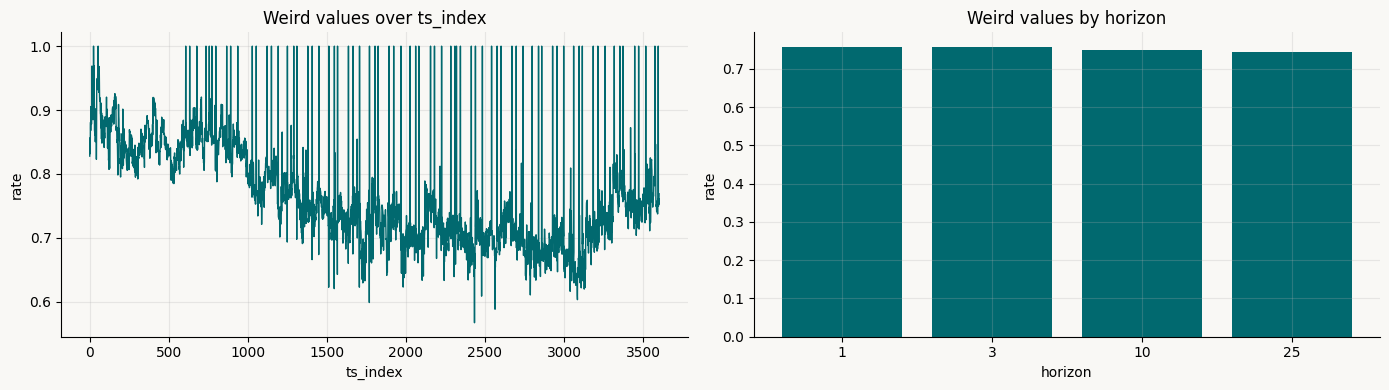

In [34]:
ts_summary = df_flags.groupby(TS_COL)["row_flag_weird_any"].mean().reset_index()
h_summary = df_flags.groupby(HORIZON_COL)["row_flag_weird_any"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ts_summary[TS_COL], ts_summary["row_flag_weird_any"], color=TEAL, lw=1)
axes[0].set_title("Weird values over ts_index")
axes[0].set_xlabel(TS_COL)
axes[0].set_ylabel("rate")

axes[1].bar(h_summary[HORIZON_COL].astype(str), h_summary["row_flag_weird_any"], color=TEAL)
axes[1].set_title("Weird values by horizon")
axes[1].set_xlabel(HORIZON_COL)
axes[1].set_ylabel("rate")

plt.tight_layout()
plt.show()


In [35]:
def get_features_for_horizon(h):
    if "feature_registry" in globals() and "selected_horizons" in feature_registry.columns:
        return feature_registry[
            feature_registry["selected_horizons"].apply(lambda xs: h in xs if isinstance(xs, list) else False)
        ]["feature"].tolist()
    return [f for f in num_features if f in df.columns]

def build_horizon_frame(h):
    out = df[df[HORIZON_COL] == h].copy()
    raw_feats = get_features_for_horizon(h)

    final_feats = []
    for f in raw_feats:
        clean_f = f"{f}__clean"
        if clean_f in out.columns:
            final_feats.append(clean_f)
        elif f in out.columns:
            final_feats.append(f)

    cols = [TARGET, WEIGHT, TS_COL, HORIZON_COL] + final_feats
    cols = [c for c in cols if c in out.columns]

    return out[cols], final_feats

horizon_frames = {}
rows = []

for h in sorted(df[HORIZON_COL].dropna().unique()):
    frame_h, feats_h = build_horizon_frame(int(h))
    horizon_frames[int(h)] = frame_h
    rows.append({
        "horizon": int(h),
        "n_rows": len(frame_h),
        "n_features": len(feats_h)
    })

horizon_summary = pd.DataFrame(rows).sort_values("horizon").reset_index(drop=True)

display(horizon_summary)

example_h = 25 if 25 in horizon_frames else int(horizon_summary["horizon"].iloc[0])
display(horizon_frames[example_h].head())


,horizon,n_rows,n_features
0,1,1394653,30
1,3,1385816,30
2,10,1337236,30
3,25,1219709,30


,y_target,weight,ts_index,horizon,feature_bz,feature_am,feature_ca,feature_by,feature_u,feature_ao,...,feature_t,feature_bm,feature_ba,feature_q,feature_bc,feature_s,feature_bb,feature_v,feature_al,feature_p
0,-0.551324,40.982572,89,25,-0.058543,0.192181,-0.001686,NaN,0.177947,17.136629,...,0.038566,1.122459,0.709292,0.021502,0.120968,0.402125,21.803950,0.091141,-0.080212,0.013162
4,-0.437398,41.948761,90,25,-0.059625,0.179294,-0.001622,-0.001452,0.202616,16.413249,...,0.069287,1.123606,1.666216,0.020966,4.089417,7.201694,15.728494,0.092606,-0.099904,0.007729
9,-1.037938,42.322662,91,25,-0.058802,0.177613,-0.001714,NaN,0.190608,15.637485,...,0.061441,1.102047,1.409499,0.021202,4.348586,2.303080,15.708903,0.092861,-0.080523,0.013753
13,-1.131236,41.834070,92,25,-0.060201,0.153521,-0.001714,NaN,0.207800,15.933479,...,0.075444,1.058524,0.672770,0.021025,6.385098,5.410410,28.653244,0.093175,-0.085658,0.019654
19,-1.081000,42.338989,93,25,-0.062907,0.162485,-0.001770,NaN,0.202199,16.133277,...,0.047774,1.068251,0.671620,0.020737,3.441114,0.292455,28.466234,0.093100,-0.069117,0.020578


Features with IC sign flip (h=1 → h=25): 6
['feature_ar', 'feature_m', 'feature_ai', 'feature_w', 'feature_b', 'feature_e']

Features with stable IC sign: 80


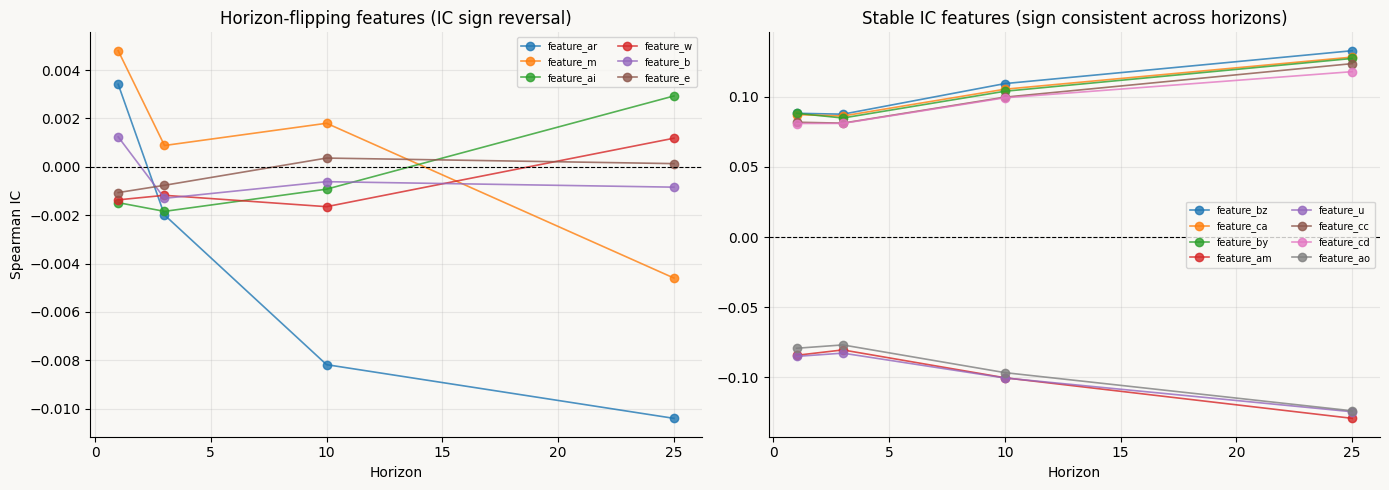

In [38]:
flip_mask = (ic_df[horizons[0]] * ic_df[horizons[-1]]) < 0
flippers  = ic_df[flip_mask].index.tolist()
stable    = ic_df[~flip_mask].index.tolist()

print(f"Features with IC sign flip (h={horizons[0]} → h={horizons[-1]}): {len(flippers)}")
print(flippers[:20])
print(f"\nFeatures with stable IC sign: {len(stable)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col in flippers[:8]:
    axes[0].plot(horizons, ic_df.loc[col, horizons].values,
                 marker="o", lw=1.2, label=col, alpha=0.8)
axes[0].axhline(0, color="black", lw=0.8, ls="--")
axes[0].set_title("Horizon-flipping features (IC sign reversal)")
axes[0].set_xlabel("Horizon")
axes[0].set_ylabel("Spearman IC")
axes[0].legend(fontsize=7, ncol=2)

for col in stable[:8]:
    axes[1].plot(horizons, ic_df.loc[col, horizons].values,
                 marker="o", lw=1.2, label=col, alpha=0.8)
axes[1].axhline(0, color="black", lw=0.8, ls="--")
axes[1].set_title("Stable IC features (sign consistent across horizons)")
axes[1].set_xlabel("Horizon")
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

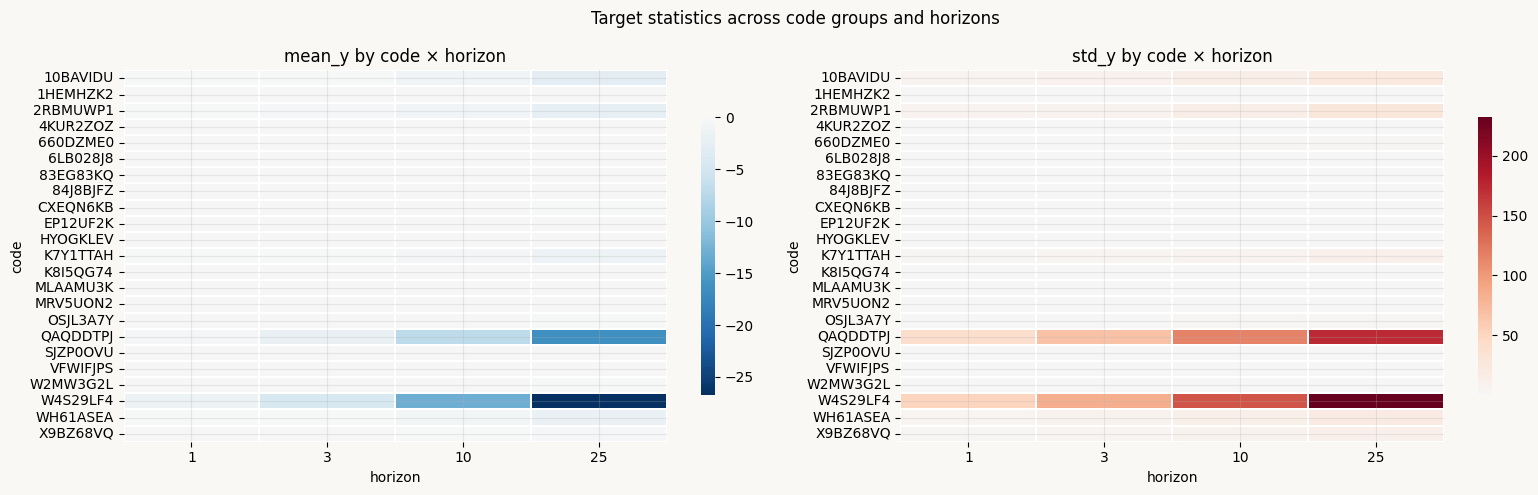

In [40]:
group_stats = (df.groupby(["code", HORIZON_COL])[TARGET]
               .agg(["mean", "std", "count"])
               .reset_index()
               .rename(columns={"mean": "mean_y", "std": "std_y", "count": "n"}))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, metric in zip(axes, ["mean_y", "std_y"]):
    pivot = group_stats.pivot(index="code", columns=HORIZON_COL, values=metric)
    sns.heatmap(pivot, ax=ax, cmap="RdBu_r", center=0,
                linewidths=0.3, cbar_kws={"shrink": 0.75})
    ax.set_title(f"{metric} by code × horizon")

plt.suptitle("Target statistics across code groups and horizons", fontsize=12)
plt.tight_layout()
plt.show()

In [41]:
series_cols = [c for c in ["id", "code", "sub_code", "sub_category", HORIZON_COL] if c in df.columns]
dup_rows = int(df.duplicated(series_cols + [TS_COL]).sum())
mono_viol = int((df.sort_values(series_cols + [TS_COL]).groupby(series_cols)[TS_COL].diff().fillna(1) < 0).sum())

unique_ts = np.array(sorted(df[TS_COL].dropna().unique()))
purge_gap = int(df[HORIZON_COL].max())
base_points = np.linspace(0.55, 0.85, 3)
fold_rows = []

for i, frac in enumerate(base_points, 1):
    train_end_idx = int(frac * (len(unique_ts) - 1))
    valid_start_idx = min(train_end_idx + purge_gap + 1, len(unique_ts) - 2)
    valid_end_idx = min(valid_start_idx + max(50, int(0.1 * len(unique_ts))), len(unique_ts) - 1)

    train_end_ts = int(unique_ts[train_end_idx])
    valid_start_ts = int(unique_ts[valid_start_idx])
    valid_end_ts = int(unique_ts[valid_end_idx])

    train_mask = df[TS_COL] <= train_end_ts
    valid_mask = (df[TS_COL] >= valid_start_ts) & (df[TS_COL] <= valid_end_ts)

    fold_rows.append({
        "fold": i,
        "train_end_ts": train_end_ts,
        "valid_start_ts": valid_start_ts,
        "valid_end_ts": valid_end_ts,
        "n_train": int(train_mask.sum()),
        "n_valid": int(valid_mask.sum())
    })

split_df = pd.DataFrame(fold_rows)
print(f"Duplicate rows on series key + ts_index: {dup_rows}")
print(f"Monotonicity violations on ts_index within series: {mono_viol}")
print(f"Purge gap used between train and validation: {purge_gap}")
print(split_df.to_string(index=False))

Duplicate rows on series key + ts_index: 0
Monotonicity violations on ts_index within series: 0
Purge gap used between train and validation: 25
 fold  train_end_ts  valid_start_ts  valid_end_ts  n_train  n_valid
    1          1981            2007          2367  2580467   609816
    2          2521            2547          2907  3495742   630897
    3          3061            3087          3447  4421059   618824


train-test consistency check 

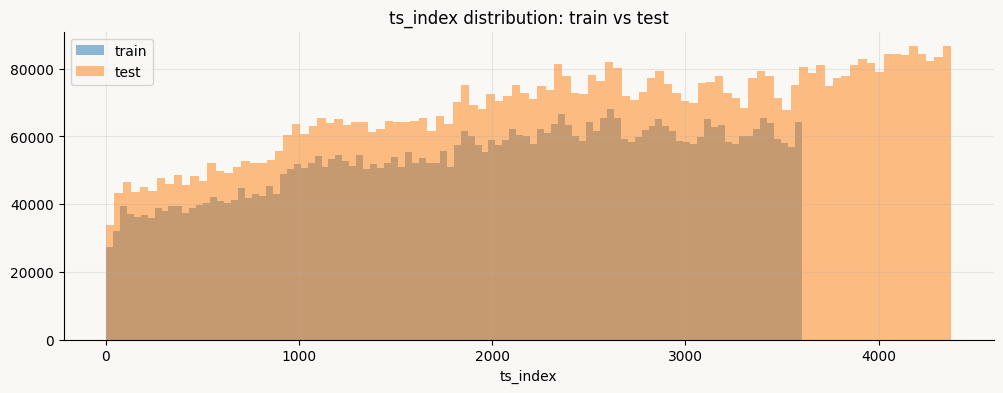

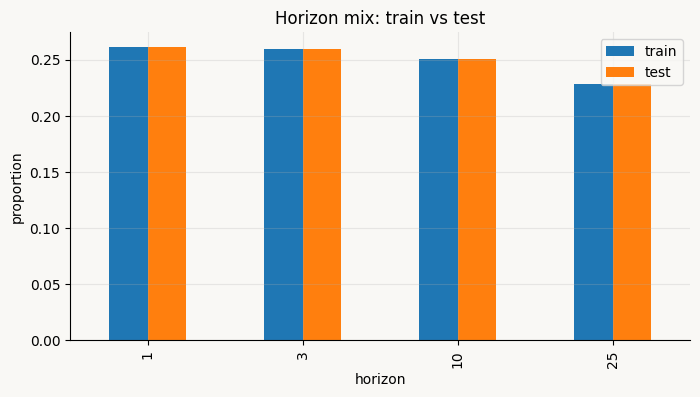

,feature,train_mean,test_mean,train_std,test_std
0,feature_a,88.6815,88.7990,56.0314,56.0139
1,feature_b,8.5674,8.5674,4.8700,4.8696
2,feature_c,8.5648,8.5650,4.8694,4.8694
3,feature_d,8.5651,8.5658,4.8715,4.8708
4,feature_e,8.5629,8.5646,4.8701,4.8701


In [39]:
from pathlib import Path

test_path = Path("/Users/raresolteanu/Downloads/ts-forecasting")

if test_path.exists():
    df_test = pd.read_parquet(test_path)

    plt.figure(figsize=(12, 4))
    plt.hist(df[TS_COL], bins=100, alpha=0.5, label="train")
    plt.hist(df_test[TS_COL], bins=100, alpha=0.5, label="test")
    plt.title("ts_index distribution: train vs test")
    plt.xlabel(TS_COL)
    plt.legend()
    plt.show()

    if HORIZON_COL in df_test.columns:
        h_compare = pd.concat([
            df[HORIZON_COL].value_counts(normalize=True).sort_index().rename("train"),
            df_test[HORIZON_COL].value_counts(normalize=True).sort_index().rename("test")
        ], axis=1).fillna(0)

        h_compare.plot(kind="bar", figsize=(8, 4))
        plt.title("Horizon mix: train vs test")
        plt.ylabel("proportion")
        plt.show()

    check_features = [c for c in num_features[:5] if c in df_test.columns]

    rows = []
    for col in check_features:
        rows.append({
            "feature": col,
            "train_mean": df[col].mean(),
            "test_mean": df_test[col].mean(),
            "train_std": df[col].std(),
            "test_std": df_test[col].std()
        })

    compare_stats = pd.DataFrame(rows)
    display(compare_stats.round(4))

else:
    print("test.parquet not found")


In [ ]:
high_missing = df[num_features].isnull().mean().sort_values(ascending=False)
drop_missing = high_missing[high_missing > 0.4].index.tolist()

feat_std = df[num_features].std()
low_var_cut = float(feat_std.quantile(0.01))
drop_low_var = feat_std[feat_std <= low_var_cut].index.tolist()

if "flagged_pairs" in globals():
    dedup_pairs = flagged_pairs[flagged_pairs["abs_r"] > 0.98].copy()
else:
    corr_tmp = df[num_features].dropna().sample(min(50000, len(df)), random_state=SEED).corr().abs()
    upper_tmp = corr_tmp.where(np.triu(np.ones(corr_tmp.shape, dtype=bool), k=1))
    dedup_pairs = upper_tmp.stack().reset_index().rename(columns={"level_0": "feat1", "level_1": "feat2", 0: "abs_r"})
    dedup_pairs = dedup_pairs[dedup_pairs["abs_r"] > 0.98].sort_values("abs_r", ascending=False)

drop_corr = dedup_pairs["feat2"].drop_duplicates().tolist()[:20]

target_scale_ratio = float(df.groupby(HORIZON_COL)[TARGET].std().max() / (df.groupby(HORIZON_COL)[TARGET].std().min() + 1e-9))
tail_kurt = float(df[TARGET].kurtosis())

drift_flagged = []
if isinstance(drift_df, pd.DataFrame) and not drift_df.empty:
    drift_flagged = drift_df[drift_df["ks_stat"] > 0.15]["feature"].head(20).tolist()

decisions = {
    "validation_protocol": "walk_forward_blocked_with_purge_gap",
    "purge_gap": int(df[HORIZON_COL].max()),
    "stationarity_action": "use_diff_or_detrend_if_level_nonstationary",
    "missing_value_strategy": "short_gap_linear_medium_gap_ffill_keep_long_gap_nan_with_flag",
    "transformation_strategy": "winsorise_then_yeojohnson_quantile_normal_for_residual_extremes",
    "features_to_drop_missing": drop_missing,
    "features_to_drop_low_variance": drop_low_var,
    "features_to_drop_high_similarity": drop_corr,
    "target_normalisation": "per_horizon_standardisation" if target_scale_ratio > 1.5 else "global_standardisation",
    "loss_function": "huber_or_mae_weighted" if tail_kurt > 3 else "weighted_mse",
    "horizon_pooling": "pooled_with_feature_horizon_interactions",
    "drift_flagged_features": drift_flagged
}

for k, v in decisions.items():
    print(f"{k:35s}: {v}")

In [44]:
print(feature_sets.keys())
for k, v in feature_sets.items():
    print(k, len(v))


dict_keys(['set_core_stable', 'set_union_compact', 'set_wide_low_prune', 'set_h1_dedup', 'set_h3_dedup', 'set_h10_dedup', 'set_h25_dedup'])
set_core_stable 25
set_union_compact 29
set_wide_low_prune 31
set_h1_dedup 28
set_h3_dedup 28
set_h10_dedup 28
set_h25_dedup 28


In [ ]:
import re

base = df_ready.copy() if "df_ready" in globals() else df.copy()

if "feature_sets" not in globals() or not isinstance(feature_sets, dict) or len(feature_sets) == 0:
    raise ValueError("feature_sets is missing or empty")

out_dir = Path("/Users/martateodoratrales/Desktop/ts-hedge/Practical_DL/feature_set_exports")
out_dir.mkdir(parents=True, exist_ok=True)

rows = []

for set_name, feats in feature_sets.items():
    if feats is None:
        continue

    feats = [f for f in list(feats) if f in base.columns]
    if len(feats) == 0:
        continue

    part = base
    m = re.fullmatch(r"set_h(\d+)_dedup", str(set_name))
    if m and HORIZON_COL in base.columns:
        h = int(m.group(1))
        part = base[base[HORIZON_COL] == h]

    out_path = out_dir / f"{set_name}.parquet"
    part.loc[:, feats].to_parquet(out_path, index=False)

    rows.append({
        "set_name": set_name,
        "horizon_filter": int(m.group(1)) if m else None,
        "n_rows": int(len(part)),
        "n_features": int(len(feats)),
        "file": str(out_path)
    })

export_summary = pd.DataFrame(rows).sort_values("set_name").reset_index(drop=True)
print(export_summary.to_string(index=False))
print(f"\nSaved {len(export_summary)} parquet files in: {out_dir}")


          set_name  horizon_filter  n_rows  n_features                                                                                                   file
   set_core_stable             NaN 5337414           8    /Users/martateodoratrales/Desktop/ts-hedge/Practical_DL/feature_set_exports/set_core_stable.parquet
     set_h10_dedup            10.0 1337236          10      /Users/martateodoratrales/Desktop/ts-hedge/Practical_DL/feature_set_exports/set_h10_dedup.parquet
      set_h1_dedup             1.0 1394653          10       /Users/martateodoratrales/Desktop/ts-hedge/Practical_DL/feature_set_exports/set_h1_dedup.parquet
     set_h25_dedup            25.0 1219709          10      /Users/martateodoratrales/Desktop/ts-hedge/Practical_DL/feature_set_exports/set_h25_dedup.parquet
      set_h3_dedup             3.0 1385816          10       /Users/martateodoratrales/Desktop/ts-hedge/Practical_DL/feature_set_exports/set_h3_dedup.parquet
 set_union_compact             NaN 5337414          